# Bakery Day Backtest

Backtest notebook for bakery-level daily forecast.

Inputs:
- `reports/bakery_day_model_holdout_predictions.csv`
- `reports/bakery_day_model_bias_by_bakery.csv`

The notebook compares:
- actual sales
- base holdout forecast
- bias-adjusted holdout forecast


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [8]:
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

HOLDOUT_PATH = ROOT / "reports" / "bakery_day_model_holdout_predictions.csv"
BIAS_PATH = ROOT / "reports" / "bakery_day_model_bias_by_bakery.csv"
BIAS_CLIP_PCT = 0.15

holdout = pd.read_csv(HOLDOUT_PATH, encoding="utf-8-sig")
bias = pd.read_csv(BIAS_PATH, encoding="utf-8-sig")

holdout["date"] = pd.to_datetime(holdout["date"], errors="coerce")
holdout["bakery_sales"] = pd.to_numeric(holdout["bakery_sales"], errors="coerce").fillna(0.0)
holdout["bakery_day_forecast"] = pd.to_numeric(holdout["bakery_day_forecast"], errors="coerce").fillna(0.0)

bias_small = bias[["bakery_id", "bias"]].copy()
bias_small["bias"] = pd.to_numeric(bias_small["bias"], errors="coerce").fillna(0.0)
bias_small = bias_small.groupby("bakery_id", as_index=False).agg(bias=("bias", "mean"))

backtest = holdout.merge(bias_small, on="bakery_id", how="left")
backtest["bias"] = backtest["bias"].fillna(0.0)
backtest["bias_adjustment_capped"] = backtest["bias"].clip(
    lower=-backtest["bakery_day_forecast"] * BIAS_CLIP_PCT,
    upper=backtest["bakery_day_forecast"] * BIAS_CLIP_PCT,
)
backtest["bakery_day_forecast_bias_adj"] = (
    backtest["bakery_day_forecast"] + backtest["bias_adjustment_capped"]
).clip(lower=0.0)

backtest["error_base"] = backtest["bakery_sales"] - backtest["bakery_day_forecast"]
backtest["error_bias_adj"] = backtest["bakery_sales"] - backtest["bakery_day_forecast_bias_adj"]
backtest = backtest.sort_values(["bakery_id", "date"]).reset_index(drop=True)

print(f"rows={len(backtest):,} | dates={backtest['date'].nunique()} | bakeries={backtest['bakery_id'].nunique()}")
display(backtest.head())


rows=5,408 | dates=30 | bakeries=182


,date,bakery_id,bakery_name,city,bakery_sales,bakery_day_forecast,bias,bias_adjustment_capped,bakery_day_forecast_bias_adj,error_base,error_bias_adj
0,2026-04-13,1,Столичная 37А Зеленодольск,Зеленодольск,759.0,912.477850,-9.978048,-9.978048,902.499802,-153.477850,-143.499802
1,2026-04-14,1,Столичная 37А Зеленодольск,Зеленодольск,779.0,909.473469,-9.978048,-9.978048,899.495421,-130.473469,-120.495421
2,2026-04-15,1,Столичная 37А Зеленодольск,Зеленодольск,820.0,922.719155,-9.978048,-9.978048,912.741108,-102.719155,-92.741108
3,2026-04-16,1,Столичная 37А Зеленодольск,Зеленодольск,938.5,924.755896,-9.978048,-9.978048,914.777848,13.744104,23.722152
4,2026-04-17,1,Столичная 37А Зеленодольск,Зеленодольск,931.5,1029.905230,-9.978048,-9.978048,1019.927183,-98.405230,-88.427183


In [3]:
def metrics_frame(df: pd.DataFrame, actual_col: str, pred_cols: list[str]) -> pd.DataFrame:
    rows = []
    actual = pd.to_numeric(df[actual_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    for pred_col in pred_cols:
        pred = pd.to_numeric(df[pred_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        rows.append(
            {
                "model": pred_col,
                "mae": float(np.mean(np.abs(actual - pred))),
                "mse": float(np.mean((actual - pred) ** 2)),
                "wmape": float(np.sum(np.abs(actual - pred)) / (np.sum(actual) + 1e-8) * 100),
                "bias": float(np.mean(actual - pred)),
                "forecast_total": float(pred.sum()),
                "actual_total": float(actual.sum()),
            }
        )
    return pd.DataFrame(rows)


overall_metrics = metrics_frame(
    backtest,
    actual_col="bakery_sales",
    pred_cols=["bakery_day_forecast", "bakery_day_forecast_bias_adj"],
)
display(overall_metrics)


,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,120.815491,30548.869505,11.059075,-4.071559,5.930019e+06,5908000.303
1,bakery_day_forecast_bias_adj,116.979183,29115.777237,10.707911,-0.055495,5.908300e+06,5908000.303


In [4]:
daily = (
    backtest.groupby("date", as_index=False)
    .agg(
        actual=("bakery_sales", "sum"),
        forecast_base=("bakery_day_forecast", "sum"),
        forecast_bias_adj=("bakery_day_forecast_bias_adj", "sum"),
    )
    .sort_values("date")
)
daily["error_base"] = daily["actual"] - daily["forecast_base"]
daily["error_bias_adj"] = daily["actual"] - daily["forecast_bias_adj"]
display(daily.head())


,date,actual,forecast_base,forecast_bias_adj,error_base,error_bias_adj
0,2026-04-13,178492.186,202972.883271,202214.920760,-24480.697271,-23722.734760
1,2026-04-14,188387.273,206186.968311,205429.005800,-17799.695311,-17041.732800
2,2026-04-15,204920.761,212379.221229,211621.258718,-7458.460229,-6700.497718
3,2026-04-16,209222.510,215628.492465,214870.529954,-6405.982465,-5648.019954
4,2026-04-17,223097.940,235569.423483,234811.460972,-12471.483483,-11713.520972


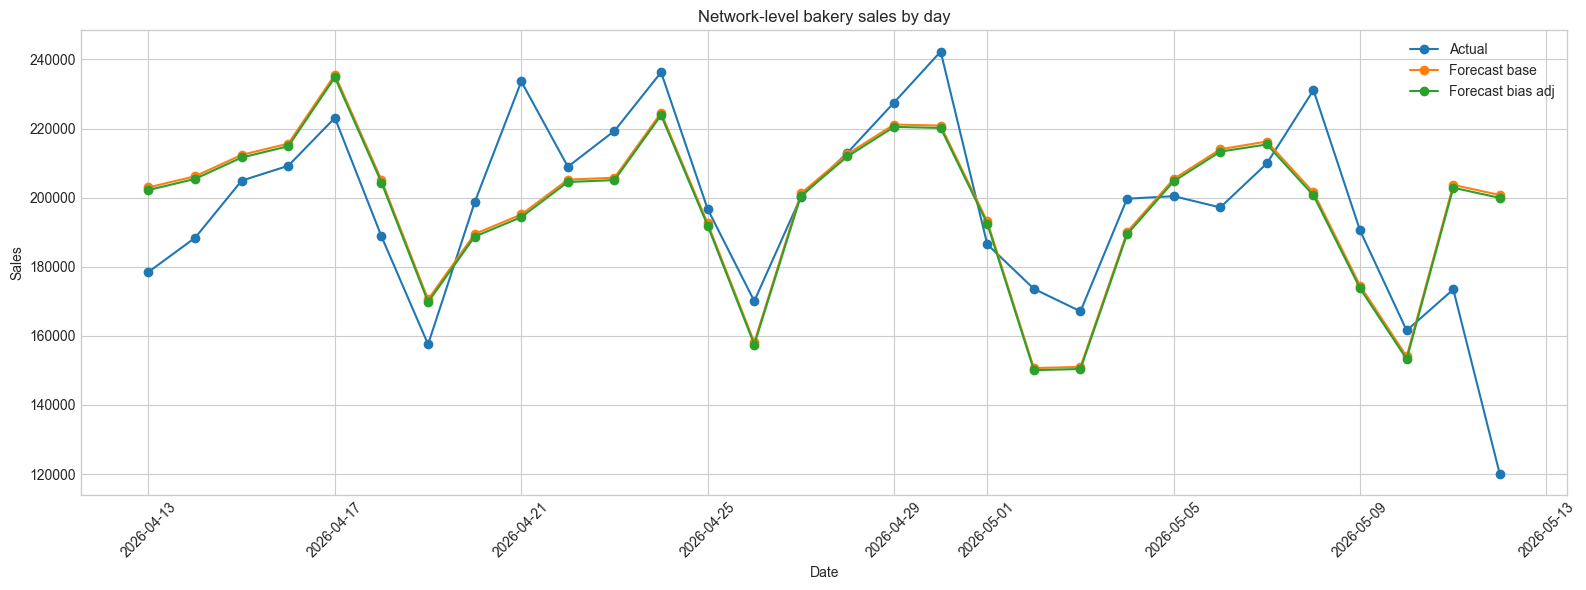

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily["date"], daily["actual"], marker="o", label="Actual")
ax.plot(daily["date"], daily["forecast_base"], marker="o", label="Forecast base")
ax.plot(daily["date"], daily["forecast_bias_adj"], marker="o", label="Forecast bias adj")
ax.set_title("Network-level bakery sales by day")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


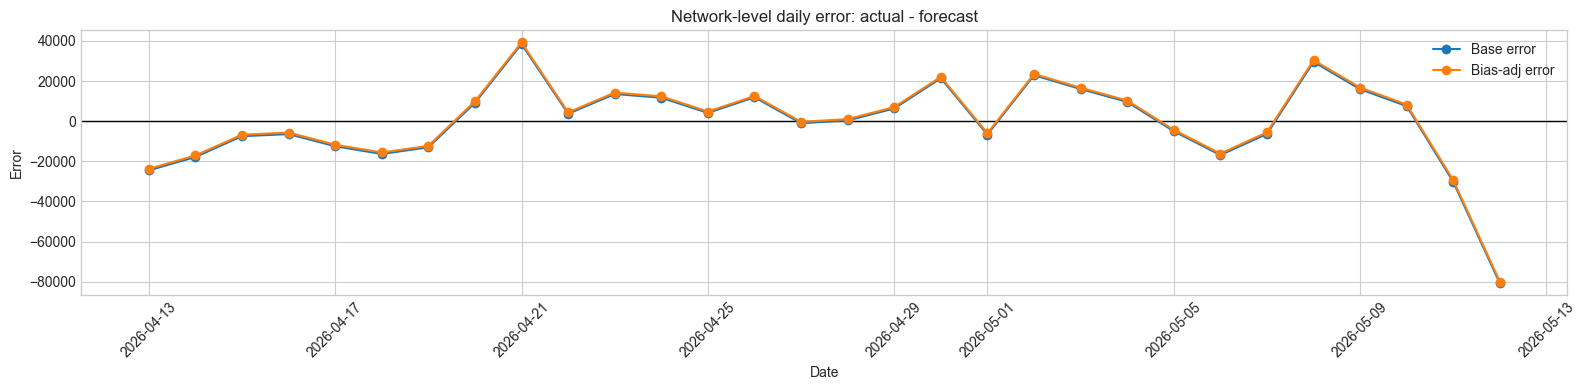

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.axhline(0.0, color="black", linewidth=1)
ax.plot(daily["date"], daily["error_base"], marker="o", label="Base error")
ax.plot(daily["date"], daily["error_bias_adj"], marker="o", label="Bias-adj error")
ax.set_title("Network-level daily error: actual - forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Error")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
bias_view = bias.copy().sort_values("abs_bias", ascending=False).reset_index(drop=True)
display(bias_view.head(20))


,bakery_id,bakery_name,city,n_days,actual_mean,forecast_mean,bias,mae,actual_sum,forecast_sum,abs_bias,bias_pct_of_actual_mean,wmape
0,262,Харьковская 3 Курск,Курск,30,1052.083333,1230.375210,-178.291877,220.904958,31562.500,36911.256312,178.291877,-16.946555,20.996907
1,142,Баки Урманче 6 Казань,Казань,30,2022.263167,2165.794616,-143.531449,190.485925,60667.895,64973.838473,143.531449,-7.097565,9.419443
2,245,"Яблоневая, 1д Габишево",Казань,30,1144.107033,1025.594432,118.512601,186.307431,34323.211,30767.832964,118.512601,10.358524,16.284091
3,249,Союзная 21 Курск,Курск,30,989.300000,1094.984582,-105.684582,148.413894,29679.000,32849.537459,105.684582,-10.682764,15.001910
4,18,Хади Такташ 105 Казань,Казань,30,1652.707500,1751.131277,-98.423777,196.199230,49581.225,52533.938314,98.423777,-5.955305,11.871383
5,231,Клыкова 92 Курск,Курск,30,844.616667,939.140918,-94.524251,148.109298,25338.500,28174.227531,94.524251,-11.191379,17.535683
6,60,Мусина 68 Казань,Казань,30,3053.533333,2963.072182,90.461151,280.998767,91606.000,88892.165473,90.461151,2.962507,9.202414
7,103,Татарстан 16 Наб Челны,Набережные Челны,30,1258.703167,1173.594576,85.108591,142.811695,37761.095,35207.837271,85.108591,6.761609,11.345939
8,116,Горького 51 Чебоксары,Чебоксары,30,1754.990000,1835.960049,-80.970049,216.697307,52649.700,55078.801483,80.970049,-4.613704,12.347495
9,86,Лемаева 2А Нижнекамск,Нижнекамск,30,1072.683900,1002.378677,70.305223,197.764795,32180.517,30071.360310,70.305223,6.554142,18.436447


In [8]:
def plot_bakery(bakery_id=None, bakery_name_contains=None):
    work = backtest.copy()
    if bakery_id is not None:
        work = work[work["bakery_id"] == bakery_id].copy()
    if bakery_name_contains is not None:
        work = work[work["bakery_name"].str.contains(bakery_name_contains, case=False, na=False)].copy()
    if work.empty:
        raise ValueError("No rows found for the requested bakery filter")

    bakery_name = work["bakery_name"].iloc[0]
    bakery_id_value = work["bakery_id"].iloc[0]
    city = work["city"].iloc[0]

    metrics = metrics_frame(
        work,
        actual_col="bakery_sales",
        pred_cols=["bakery_day_forecast", "bakery_day_forecast_bias_adj"],
    )
    display(metrics)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    axes[0].plot(work["date"], work["bakery_sales"], marker="o", label="Actual")
    axes[0].plot(work["date"], work["bakery_day_forecast"], marker="o", label="Forecast base")
    axes[0].plot(work["date"], work["bakery_day_forecast_bias_adj"], marker="o", label="Forecast bias adj")
    axes[0].set_title(f"Bakery {bakery_id_value} | {bakery_name} | {city}")
    axes[0].set_ylabel("Sales")
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].plot(work["date"], work["error_base"], marker="o", label="Base error")
    axes[1].plot(work["date"], work["error_bias_adj"], marker="o", label="Bias-adj error")
    axes[1].set_ylabel("Error")
    axes[1].set_xlabel("Date")
    axes[1].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,124.59227,36669.969362,7.100893,1.596854e+01,52158.94389,52638.0
1,bakery_day_forecast_bias_adj,125.16761,36414.975188,7.133683,-9.852859e-14,52638.00000,52638.0


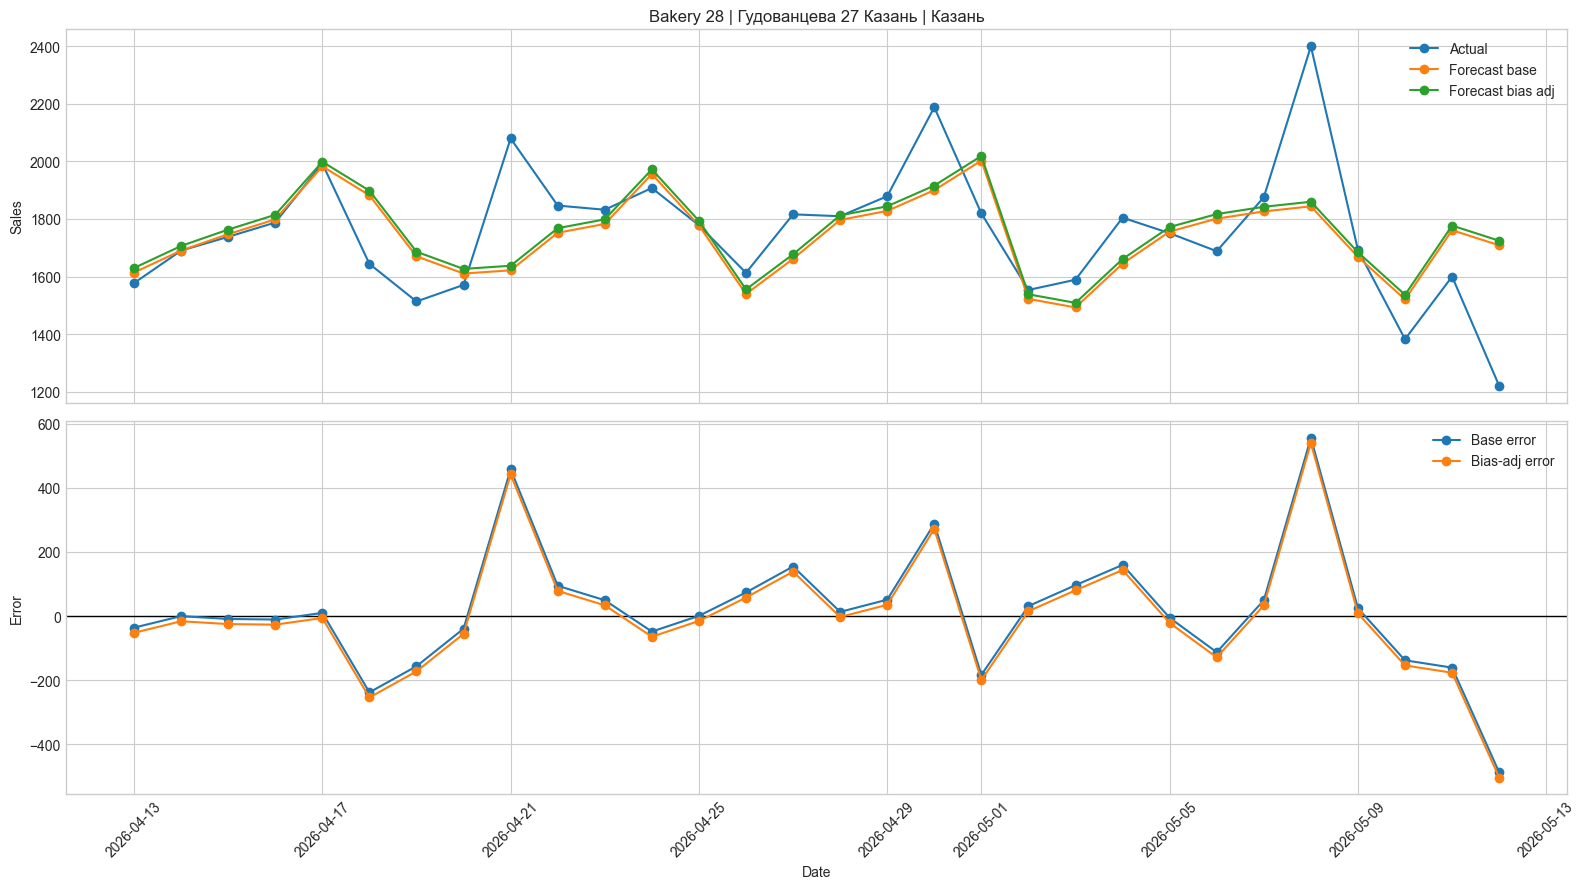

,model,mae,mse,wmape,bias,forecast_total,actual_total
0,bakery_day_forecast,186.307431,62042.534796,16.284091,1.185126e+02,30767.832964,34323.211
1,bakery_day_forecast_bias_adj,163.208807,47997.298152,14.265169,-1.515825e-14,34323.211000,34323.211


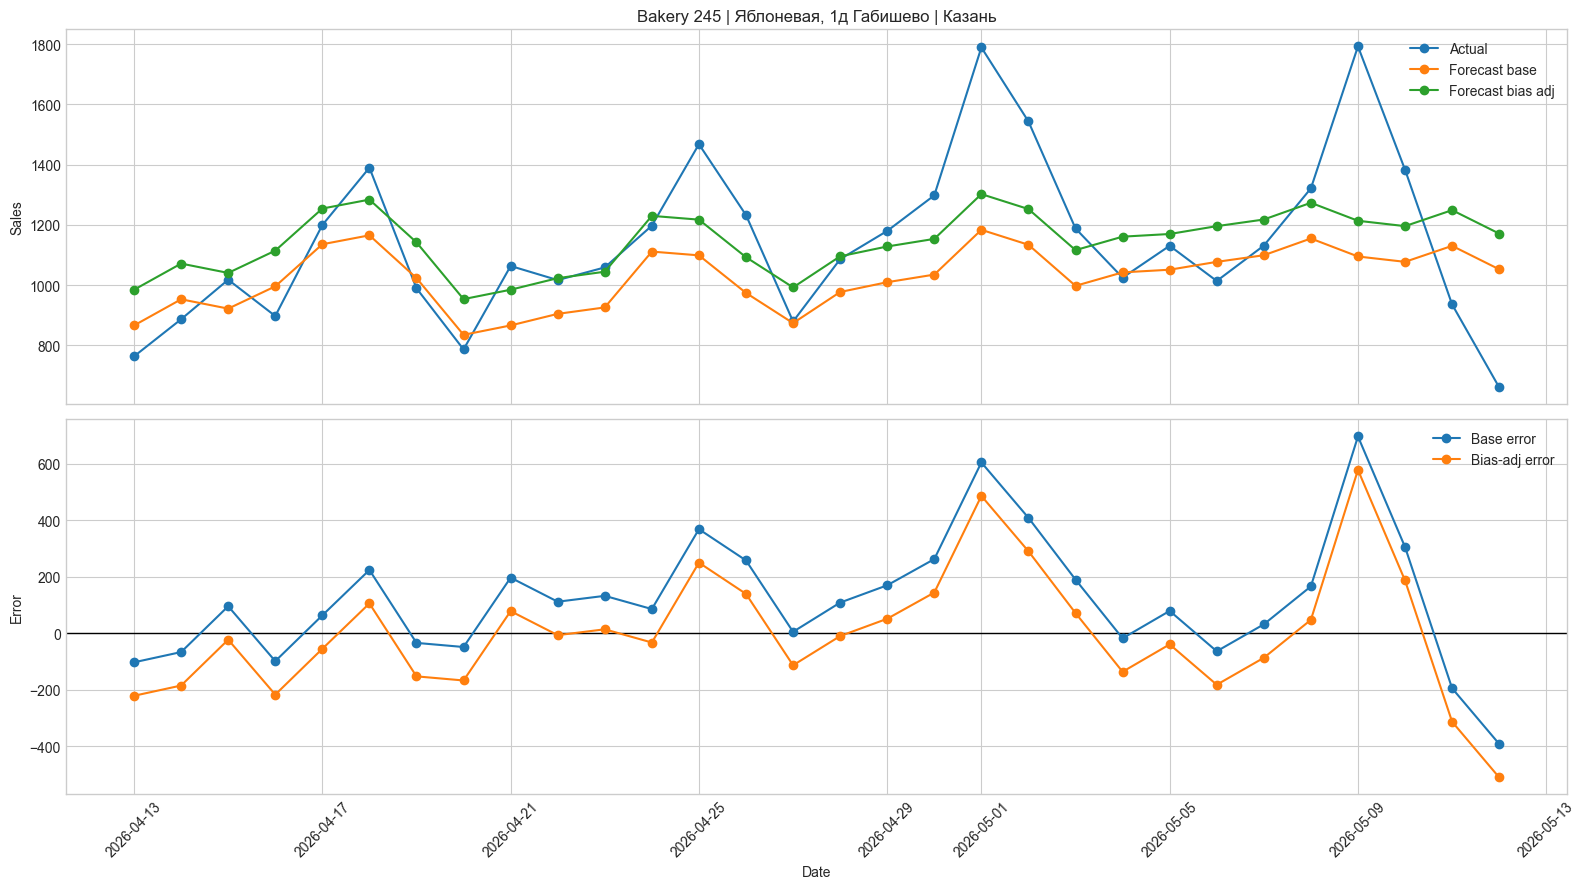

In [42]:
# Examples: inspect the strongest shifted bakeries from holdout.
plot_bakery(bakery_id=28)
plot_bakery(bakery_id=245)


In [10]:
bakery_metrics = []
for bakery_id, group in backtest.groupby("bakery_id", sort=False):
    metric_df = metrics_frame(group, "bakery_sales", ["bakery_day_forecast", "bakery_day_forecast_bias_adj"])
    base = metric_df[metric_df["model"] == "bakery_day_forecast"].iloc[0]
    adj = metric_df[metric_df["model"] == "bakery_day_forecast_bias_adj"].iloc[0]
    bakery_metrics.append(
        {
            "bakery_id": bakery_id,
            "bakery_name": group["bakery_name"].iloc[0],
            "city": group["city"].iloc[0],
            "base_mae": base["mae"],
            "adj_mae": adj["mae"],
            "mae_delta": adj["mae"] - base["mae"],
            "base_bias": base["bias"],
            "adj_bias": adj["bias"],
            "abs_bias_delta": abs(adj["bias"]) - abs(base["bias"]),
        }
    )

bakery_metrics = pd.DataFrame(bakery_metrics)
print("Bias-adjusted forecast improved MAE for bakeries:", int((bakery_metrics['mae_delta'] < 0).sum()))
print("Bias-adjusted forecast reduced abs(bias) for bakeries:", int((bakery_metrics['abs_bias_delta'] < 0).sum()))
display(bakery_metrics.sort_values("mae_delta").head(20))
display(bakery_metrics.sort_values("mae_delta", ascending=False).head(20))


Bias-adjusted forecast improved MAE for bakeries: 128
Bias-adjusted forecast reduced abs(bias) for bakeries: 182


,bakery_id,bakery_name,city,base_mae,adj_mae,mae_delta,base_bias,adj_bias,abs_bias_delta
176,262,Харьковская 3 Курск,Курск,220.904958,146.124383,-74.780575,-178.291877,-6.841357e+00,-171.450521
83,103,Татарстан 16 Наб Челны,Набережные Челны,142.811695,100.859163,-41.952532,85.108591,9.852859e-14,-85.108591
166,249,Союзная 21 Курск,Курск,148.413894,116.225451,-32.188443,-105.684582,1.894781e-14,-105.684582
147,218,Проспект Победы 147 Казань,Казань,93.048538,63.434819,-29.613719,64.772760,2.652693e-14,-64.772760
164,245,"Яблоневая, 1д Габишево",Казань,186.307431,163.208807,-23.098624,118.512601,-1.515825e-14,-118.512601
117,160,Альфии Авзаловой 5 Казань,Казань,137.802639,116.828492,-20.974146,59.797861,-3.789561e-15,-59.797861
95,117,Дубравная 51Г Казань,Казань,256.419546,236.111674,-20.307872,46.761688,-1.440033e-13,-46.761688
103,142,Баки Урманче 6 Казань,Казань,190.485925,171.563585,-18.922341,-143.531449,9.094947e-14,-143.531449
155,231,Клыкова 92 Курск,Курск,148.109298,131.033261,-17.076037,-94.524251,-3.373458e-01,-94.186905
61,72,Сахарова 27 Казань,Казань,116.234285,99.907452,-16.326833,-65.196998,4.547474e-14,-65.196998


,bakery_id,bakery_name,city,base_mae,adj_mae,mae_delta,base_bias,adj_bias,abs_bias_delta
78,94,Розы Люксембург 4 Чебоксары,Чебоксары,126.156056,130.643880,4.487824,-35.845249,-1.136868e-13,-35.845249
110,152,Менделеева 35А Нижнекамск,Нижнекамск,85.355503,89.800098,4.444595,-23.772250,3.221127e-14,-23.772250
43,48,Гаврилова 40 Казань,Казань,98.449781,102.669966,4.220184,23.447280,1.894781e-14,-23.447280
9,11,Фучика 72 Казань,Казань,149.283296,152.845114,3.561817,32.649012,-4.168517e-14,-32.649012
79,95,Сармановский тракт 18/38А Наб Челны,Набережные Челны,136.030134,139.343703,3.313568,-30.752188,-1.136868e-14,-30.752188
59,70,Комсомольская 52Б Заинск,Заинск,164.013768,166.987755,2.973987,-25.896496,1.515825e-14,-25.896496
0,1,Столичная 37А Зеленодольск,Зеленодольск,90.637685,93.298498,2.660813,-9.978048,-1.136868e-14,-9.978048
102,137,Татарстан 53А Казань,Казань,201.665343,204.194829,2.529486,-24.475378,9.094947e-14,-24.475378
126,172,Винокурова 28 Новочебоксарск,Чебоксары,119.966465,122.424613,2.458148,-13.459272,3.789561e-14,-13.459272
73,89,Парина 6 Казань,Казань,181.809695,184.110961,2.301265,-12.220612,3.789561e-15,-12.220612


bakery_id=245 | Яблоневая, 1д Габишево | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,186.307431,118.512601,1144.107033,1025.594432
1,fast_seasonal,177.480455,122.153632,1144.107033,1021.953401


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,763.560,866.140747,828.992225,-102.580747,-65.432225
1,2026-04-14,886.720,953.004173,856.909219,-66.284173,29.810781
2,2026-04-15,1017.965,921.984236,877.670908,95.980764,140.294092
3,2026-04-16,897.455,995.920781,971.432756,-98.465781,-73.977756
4,2026-04-17,1199.357,1135.608334,1064.946960,63.748666,134.410040
5,2026-04-18,1389.715,1165.296705,990.377773,224.418295,399.337227
6,2026-04-19,989.575,1023.420429,975.379924,-33.845429,14.195076
7,2026-04-20,786.620,835.011079,772.745254,-48.391079,13.874746
8,2026-04-21,1063.481,866.244907,859.460499,197.236093,204.020501
9,2026-04-22,1016.692,904.643934,943.567748,112.048066,73.124252


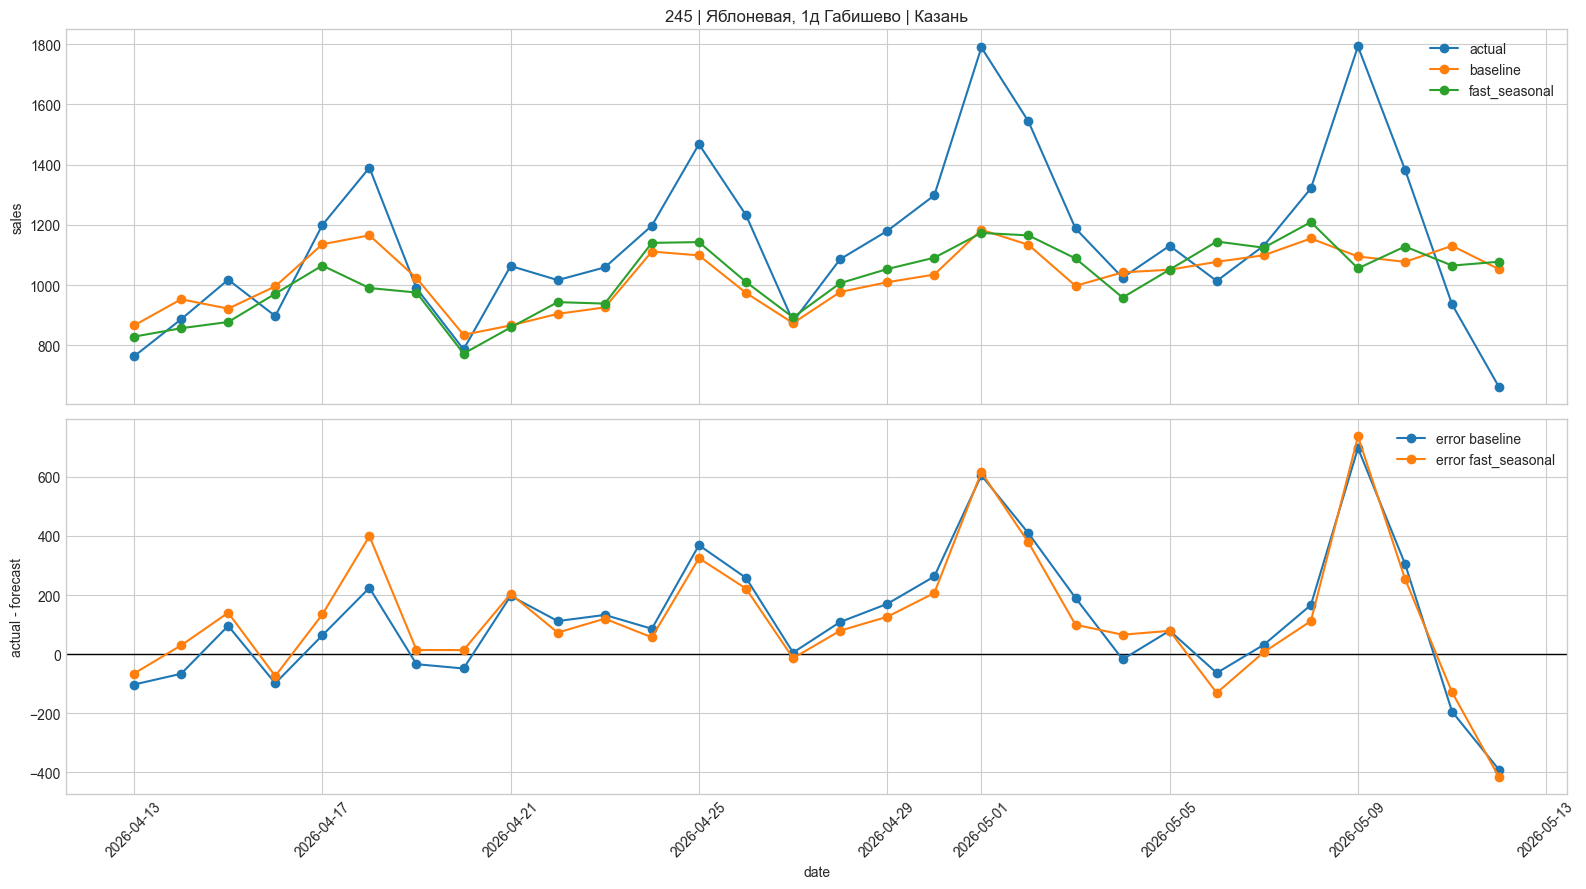

bakery_id=262 | Харьковская 3 Курск | Курск


,model,mae,bias,actual_mean,forecast_mean
0,baseline,220.904958,-178.291877,1052.083333,1230.375210
1,fast_seasonal,194.241416,-109.832266,1052.083333,1161.915599


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,948.0,1412.682165,1158.723504,-464.682165,-210.723504
1,2026-04-14,1057.0,1274.937489,1122.475640,-217.937489,-65.475640
2,2026-04-15,929.0,1248.704941,1197.389771,-319.704941,-268.389771
3,2026-04-16,917.0,1360.658871,1255.713243,-443.658871,-338.713243
4,2026-04-17,1177.0,1628.259008,1519.874756,-451.259008,-342.874756
5,2026-04-18,1557.0,1421.738303,1206.934487,135.261697,350.065513
6,2026-04-19,983.0,1333.892797,1140.585753,-350.892797,-157.585753
7,2026-04-20,1470.0,1198.655887,1004.243308,271.344113,465.756692
8,2026-04-21,1065.0,1424.980108,1288.511957,-359.980108,-223.511957
9,2026-04-22,1036.0,1280.422269,1103.827660,-244.422269,-67.827660


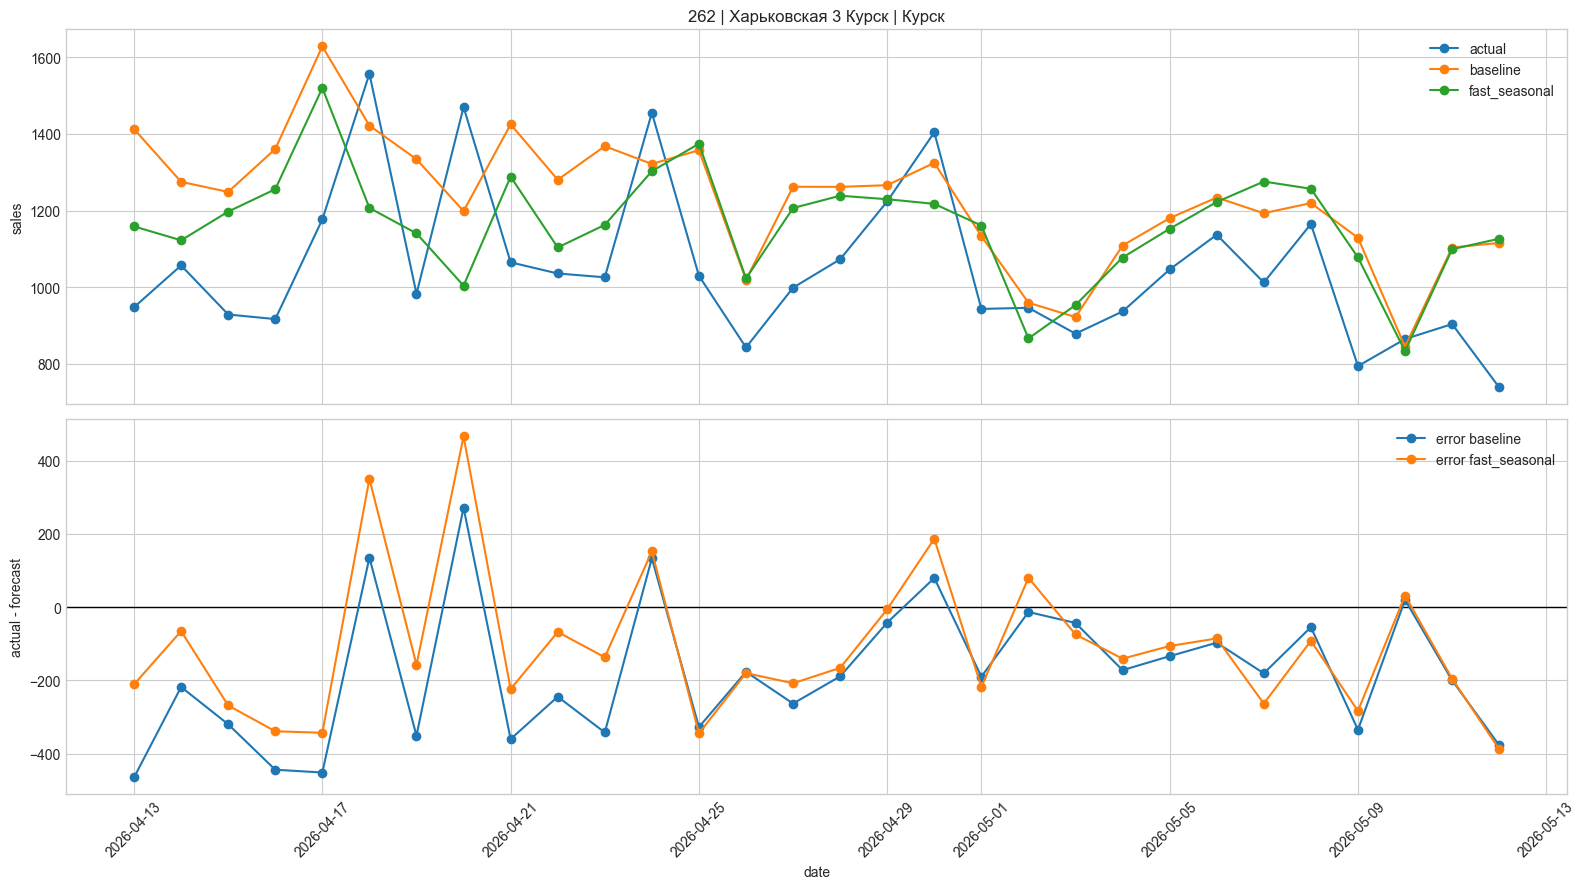

bakery_id=60 | Мусина 68 Казань | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,280.998767,90.461151,3053.533333,2963.072182
1,fast_seasonal,411.164857,251.355389,3053.533333,2802.177945


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,2632.0,2689.610124,1950.799224,-57.610124,681.200776
1,2026-04-14,2798.0,2738.774603,2052.206646,59.225397,745.793354
2,2026-04-15,2881.0,2925.948384,2229.382615,-44.948384,651.617385
3,2026-04-16,2822.0,3016.566820,2252.723217,-194.566820,569.276783
4,2026-04-17,3786.0,3209.667133,2417.855532,576.332867,1368.144468
5,2026-04-18,3038.0,3107.872106,2056.593252,-69.872106,981.406748
6,2026-04-19,2930.0,2820.337428,1993.076324,109.662572,936.923676
7,2026-04-20,2794.0,2788.421565,2705.147500,5.578435,88.852500
8,2026-04-21,3624.0,3007.202899,2983.067074,616.797101,640.932926
9,2026-04-22,3014.0,2968.781362,3246.372314,45.218638,-232.372314


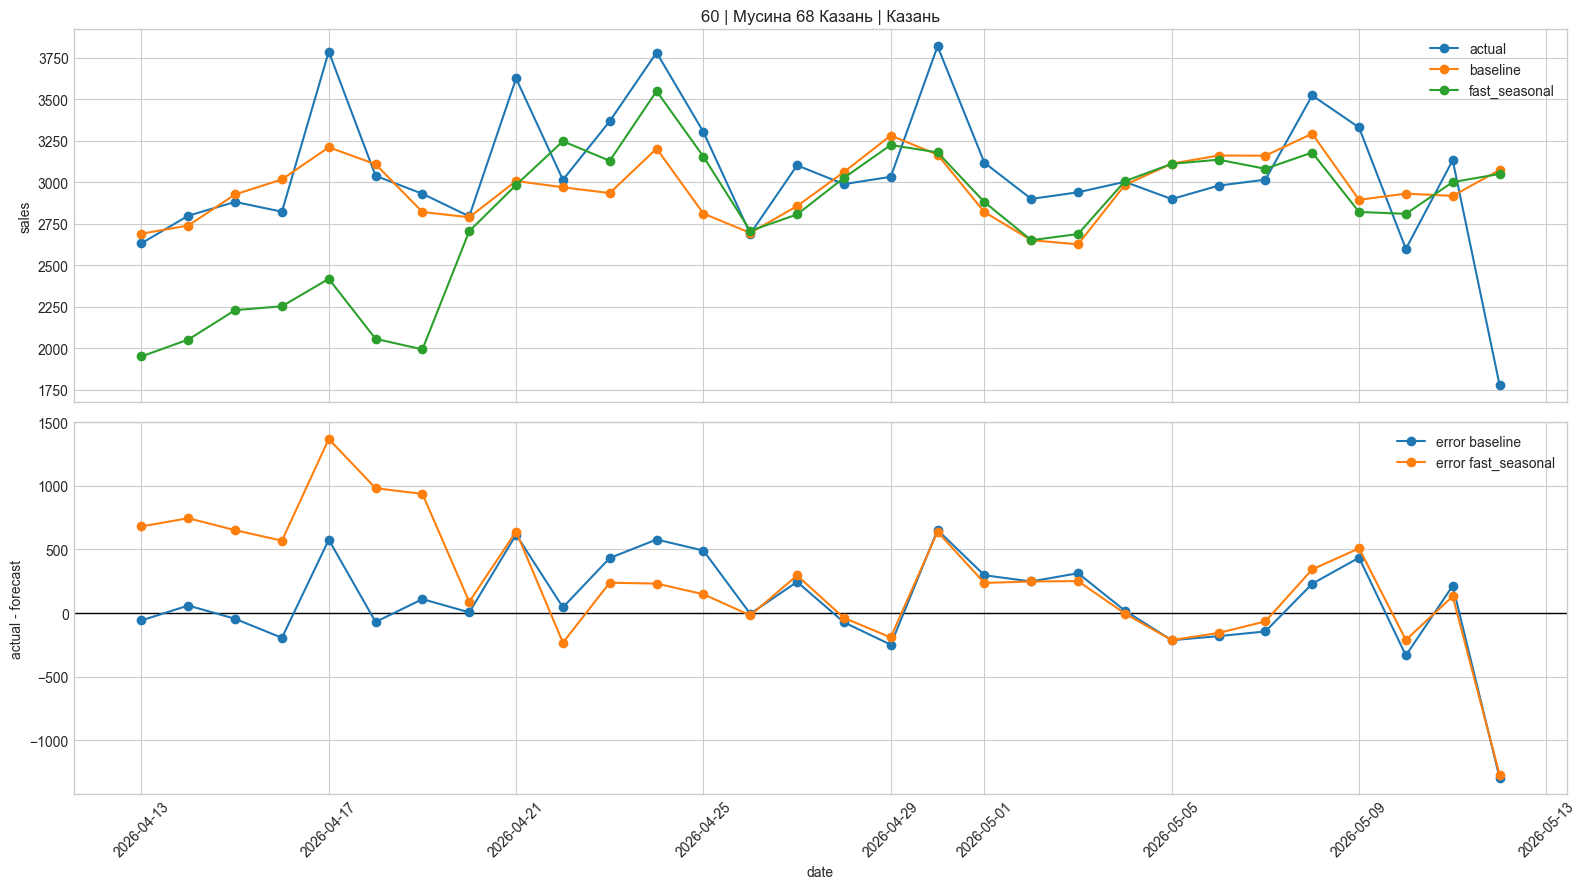

bakery_id=122 | Проспект Победы 46В Казань | Казань


,model,mae,bias,actual_mean,forecast_mean
0,baseline,112.11132,-3.091612,983.2457,986.337312
1,fast_seasonal,113.26181,23.826945,983.2457,959.418755


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,977.191,1043.567267,1003.874132,-66.376267,-26.683132
1,2026-04-14,1075.048,1088.927109,1016.487741,-13.879109,58.560259
2,2026-04-15,1057.931,1131.994255,1053.267056,-74.063255,4.663944
3,2026-04-16,1152.802,1138.840090,1067.162258,13.961910,85.639742
4,2026-04-17,1007.232,1255.383926,1147.923609,-248.151926,-140.691609
5,2026-04-18,962.287,1066.199927,895.013724,-103.912927,67.273276
6,2026-04-19,597.384,846.240145,741.142212,-248.856145,-143.758212
7,2026-04-20,1057.011,976.641367,917.263722,80.369633,139.747278
8,2026-04-21,1172.527,1003.202283,978.358598,169.324717,194.168402
9,2026-04-22,1017.109,1038.667472,1034.562879,-21.558472,-17.453879


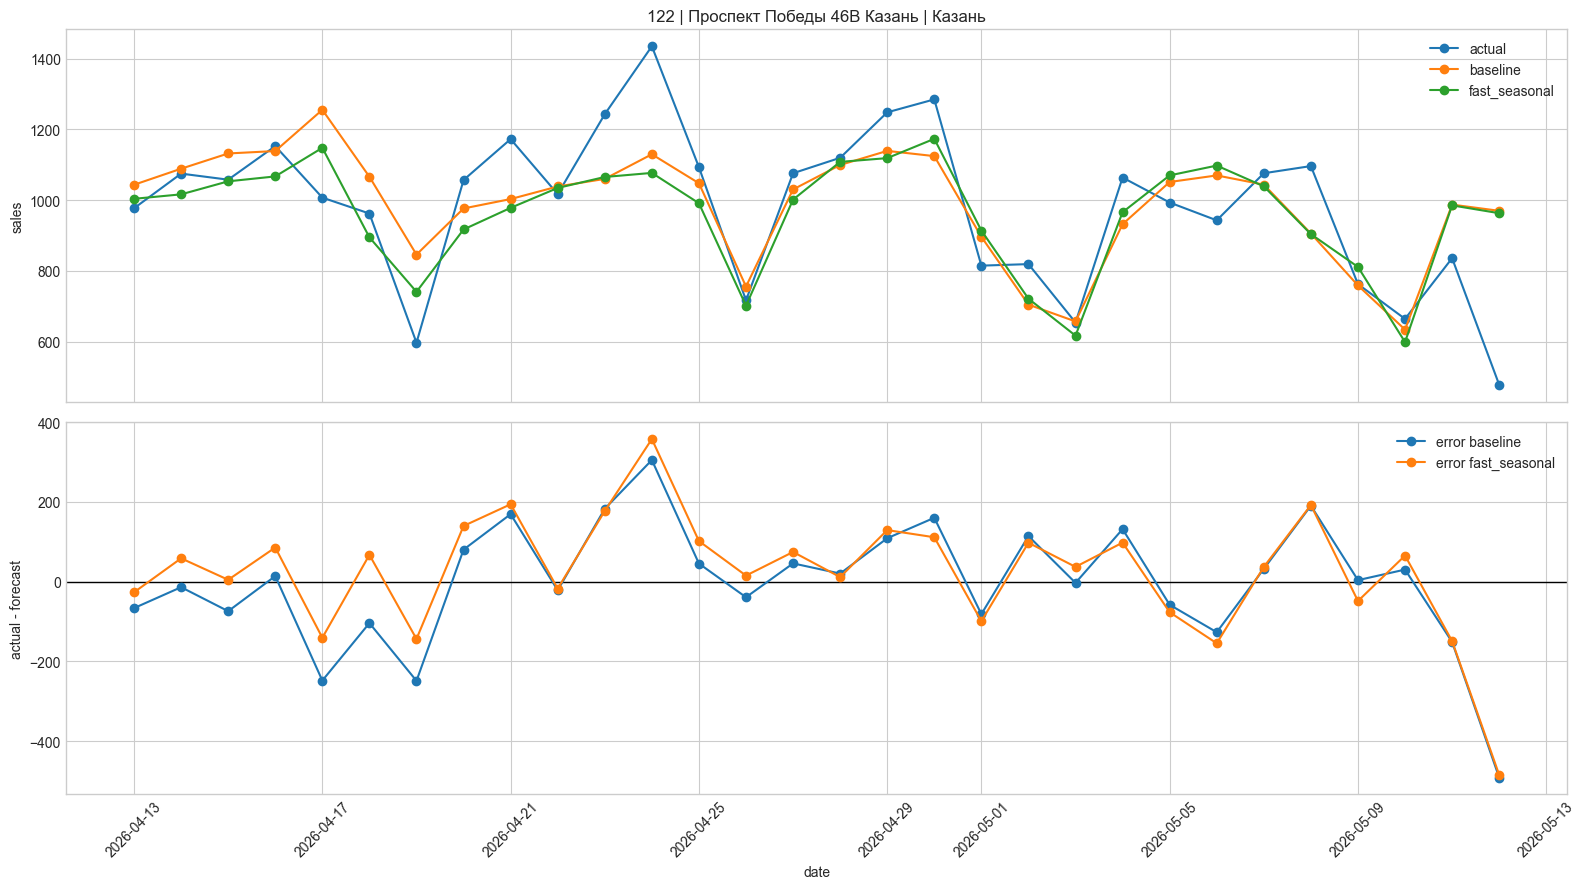

bakery_id=128: no rows
bakery_id=129: no rows
bakery_id=127: no rows
bakery_id=130 | Сармановский тракт 68 Наб Челны | Набережные Челны


,model,mae,bias,actual_mean,forecast_mean
0,baseline,72.533311,8.240207,664.649467,656.409260
1,fast_seasonal,67.152669,23.725246,664.649467,640.924221


,date,bakery_sales,pred_base,pred_fast,err_base,err_fast
0,2026-04-13,606.224,675.505218,608.169029,-69.281218,-1.945029
1,2026-04-14,547.888,668.615905,636.643267,-120.727905,-88.755267
2,2026-04-15,626.673,698.446244,645.724535,-71.773244,-19.051535
3,2026-04-16,655.943,700.210168,675.329090,-44.267168,-19.386090
4,2026-04-17,706.359,756.297656,714.088084,-49.938656,-7.729084
5,2026-04-18,639.930,686.012099,620.081132,-46.082099,19.848868
6,2026-04-19,497.513,584.781375,575.273629,-87.268375,-77.760629
7,2026-04-20,593.850,619.667269,586.568740,-25.817269,7.281260
8,2026-04-21,777.472,607.238797,570.672661,170.233203,206.799339
9,2026-04-22,722.840,653.848502,640.427765,68.991498,82.412235


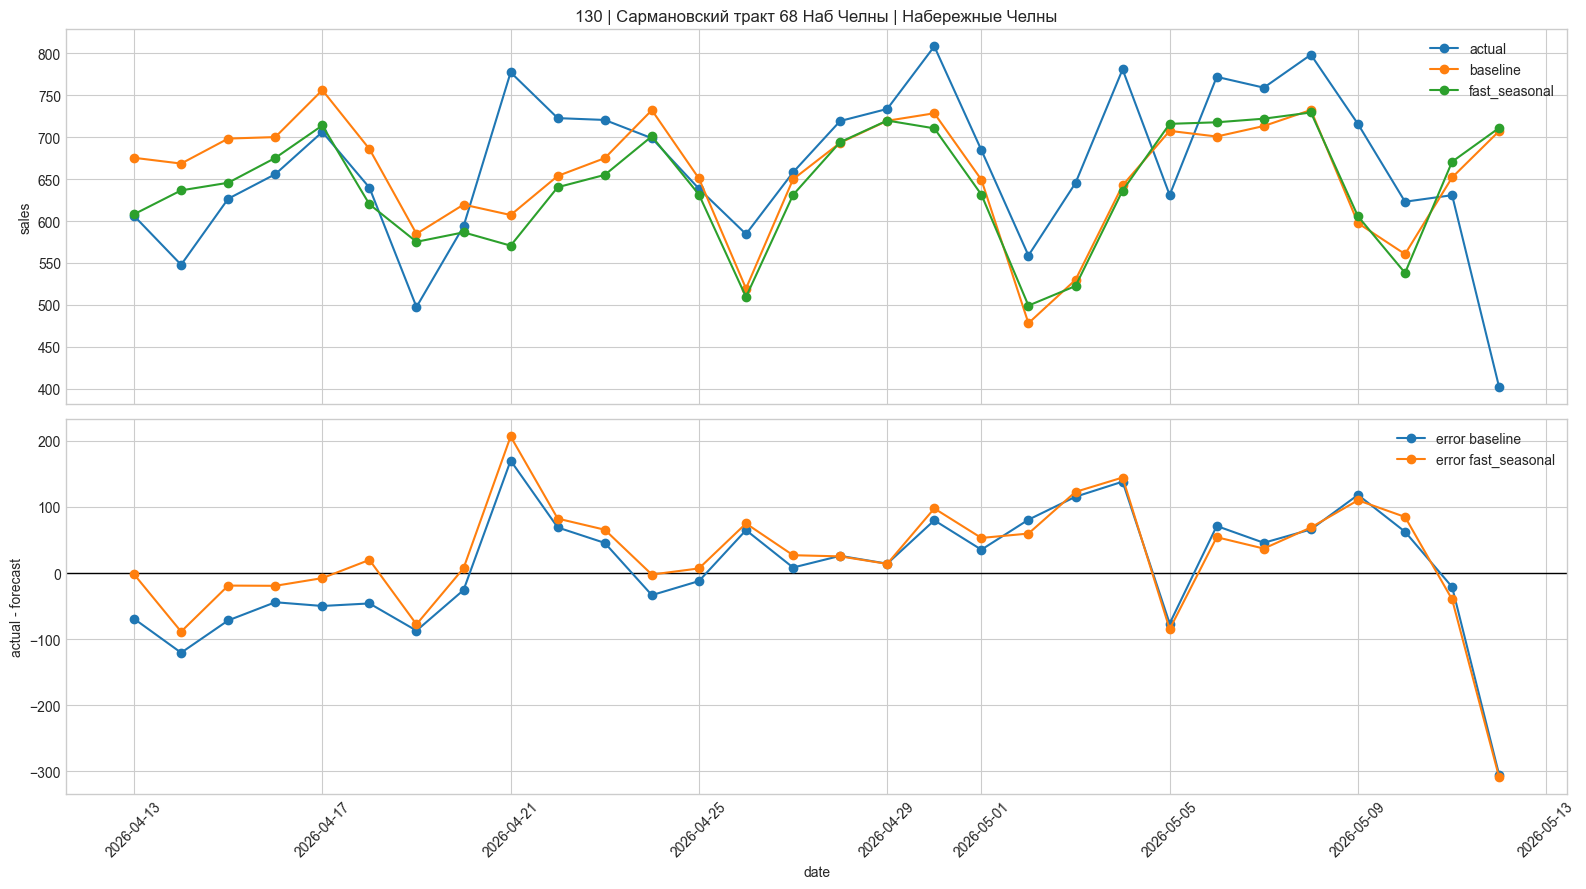

bakery_id=131: no rows
bakery_id=132: no rows


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

base = pd.read_csv(
    ROOT / "src" / "experiments_v2" / "72_bakery_regime_shift" / "predictions_baseline_global_lgbm.csv",
    encoding="utf-8-sig",
)
fast = pd.read_csv(
    ROOT / "src" / "experiments_v2" / "72_bakery_regime_shift" / "predictions_fast_seasonal_lgbm.csv",
    encoding="utf-8-sig",
)

for df in [base, fast]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

cmp_df = base.merge(
    fast[["date", "bakery_id", "prediction"]].rename(columns={"prediction": "pred_fast"}),
    on=["date", "bakery_id"],
    how="inner",
)
cmp_df = cmp_df.rename(columns={"prediction": "pred_base"})
cmp_df["err_base"] = cmp_df["bakery_sales"] - cmp_df["pred_base"]
cmp_df["err_fast"] = cmp_df["bakery_sales"] - cmp_df["pred_fast"]
cmp_df.head()

def show_bakery_compare(bakery_id: int):
    sub = cmp_df[cmp_df["bakery_id"] == bakery_id].sort_values("date").copy()
    if sub.empty:
        print(f"bakery_id={bakery_id}: no rows")
        return

    bakery_name = sub["bakery_name"].iloc[0]
    city = sub["city"].iloc[0]

    metrics = pd.DataFrame(
        [
            {
                "model": "baseline",
                "mae": sub["err_base"].abs().mean(),
                "bias": sub["err_base"].mean(),
                "actual_mean": sub["bakery_sales"].mean(),
                "forecast_mean": sub["pred_base"].mean(),
            },
            {
                "model": "fast_seasonal",
                "mae": sub["err_fast"].abs().mean(),
                "bias": sub["err_fast"].mean(),
                "actual_mean": sub["bakery_sales"].mean(),
                "forecast_mean": sub["pred_fast"].mean(),
            },
        ]
    )

    print(f"bakery_id={bakery_id} | {bakery_name} | {city}")
    display(metrics)
    display(
        sub[
            ["date", "bakery_sales", "pred_base", "pred_fast", "err_base", "err_fast"]
        ].reset_index(drop=True)
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

    axes[0].plot(sub["date"], sub["bakery_sales"], marker="o", label="actual")
    axes[0].plot(sub["date"], sub["pred_base"], marker="o", label="baseline")
    axes[0].plot(sub["date"], sub["pred_fast"], marker="o", label="fast_seasonal")
    axes[0].set_title(f"{bakery_id} | {bakery_name} | {city}")
    axes[0].set_ylabel("sales")
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].plot(sub["date"], sub["err_base"], marker="o", label="error baseline")
    axes[1].plot(sub["date"], sub["err_fast"], marker="o", label="error fast_seasonal")
    axes[1].set_ylabel("actual - forecast")
    axes[1].set_xlabel("date")
    axes[1].legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for bakery_id in [245, 262, 60, 122, 128, 129, 127, 130, 131, 132]:
    show_bakery_compare(bakery_id)

## Latest Exp73 Models

This section loads the latest strict recursive backtest artifacts from `src/experiments_v2/73_weekly_total_recursive/` and plots:
- `recursive_daily_baseline`
- `heuristic_blend_recursive`
- `seasonal_naive_lag7_recursive`


In [4]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.bakery_day_backtest_latest_models import build_bakery_model_summary
from notebooks.bakery_day_backtest_latest_models import build_model_summary
from notebooks.bakery_day_backtest_latest_models import load_exp73_backtest
from notebooks.bakery_day_backtest_latest_models import plot_bakery_forecast
from notebooks.bakery_day_backtest_latest_models import plot_network_forecast

latest_backtest = load_exp73_backtest(ROOT)
latest_summary = build_model_summary(latest_backtest)
latest_bakery_summary = build_bakery_model_summary(latest_backtest)

display(latest_summary)
display(latest_bakery_summary.sort_values("blend_minus_baseline_mae").head(20))
display(latest_bakery_summary.sort_values("lag7_minus_blend_mae").head(20))


,model,n_bakeries,n_days,forecast_total,actual_total,mae,mse,wmape,bias
0,blend,182,14,2.733934e+06,2708291.32,153.852626,60499.136993,14.588296,-9.985556
1,baseline,182,14,2.673388e+06,2708291.32,155.854180,59323.897977,14.778083,13.591550
2,lag7,182,14,2.893094e+06,2708291.32,181.433336,80198.443009,17.203497,-71.963629


,bakery_id,bakery_name,city,lag7_mae,lag7_wmape,lag7_bias,baseline_mae,baseline_wmape,baseline_bias,blend_mae,blend_wmape,blend_bias,best_model,best_mae,blend_minus_baseline_mae,lag7_minus_blend_mae
174,60,Мусина 68 Казань,Казань,284.000000,9.453162,-173.000000,442.686047,14.735151,115.142379,286.968250,9.551963,27.597747,lag7,284.000000,-155.717798,-2.968250
142,245,"Яблоневая, 1д Габишево",Казань,175.674143,14.142400,108.147000,296.678965,23.883723,247.113910,215.945129,17.384359,159.252278,lag7,175.674143,-80.733836,-40.270986
112,160,Альфии Авзаловой 5 Казань,Казань,167.834357,15.993737,-75.218214,183.586272,17.494812,96.484909,129.148997,12.307224,13.697698,blend,129.148997,-54.437274,38.685360
71,99,Сыртлановой 16 Казань,Казань,126.512500,9.933836,-110.485357,159.425755,12.518204,54.783543,105.121802,8.254226,5.636243,blend,105.121802,-54.303953,21.390698
81,47,Вагапова 3 Казань,Казань,183.766571,13.795458,-105.130143,159.305969,11.959187,43.630467,112.614237,8.454013,2.413265,blend,112.614237,-46.691732,71.152334
49,176,Радужная 7 Чебоксары,Чебоксары,164.756357,15.580259,-140.187357,140.822761,13.316968,1.891432,94.174537,8.905658,-52.247466,blend,94.174537,-46.648224,70.581820
5,263,Серова 26 Казань,Казань,84.326714,11.024669,-73.786286,93.580176,12.234444,31.052042,55.695612,7.281508,-14.395931,blend,55.695612,-37.884564,28.631102
113,228,Яраткан 1 Казань,Казань,177.102000,14.109741,-72.362286,168.545852,13.428071,106.048168,132.132275,10.526997,4.307593,blend,132.132275,-36.413578,44.969725
169,116,Горького 51 Чебоксары,Чебоксары,242.400000,13.834940,30.942857,265.028558,15.126461,-91.565290,229.941737,13.123886,32.406948,blend,229.941737,-35.086821,12.458263
118,19,Хади Такташ 73 Казань,Казань,178.323429,13.115544,-128.053286,169.217237,12.445791,-52.489447,134.851394,9.918211,-41.551343,blend,134.851394,-34.365844,43.472035


,bakery_id,bakery_name,city,lag7_mae,lag7_wmape,lag7_bias,baseline_mae,baseline_wmape,baseline_bias,blend_mae,blend_wmape,blend_bias,best_model,best_mae,blend_minus_baseline_mae,lag7_minus_blend_mae
79,84,Кулахметова 19Б Казань,Казань,111.770000,9.691371,-24.911143,187.130651,16.225754,28.037899,156.300437,13.552523,59.424043,lag7,111.770000,-30.830214,-44.530437
142,245,"Яблоневая, 1д Габишево",Казань,175.674143,14.142400,108.147000,296.678965,23.883723,247.113910,215.945129,17.384359,159.252278,lag7,175.674143,-80.733836,-40.270986
139,39,Школьная 14А Васильево,Зеленодольск,166.103786,13.058362,89.969500,221.127765,17.384109,134.456940,205.480990,16.154027,144.826112,lag7,166.103786,-15.646775,-39.377205
103,15,Чуйкова 40 Казань,Казань,125.178571,9.668165,-32.964286,167.358466,12.925929,41.358355,162.047319,12.515723,77.225282,lag7,125.178571,-5.311147,-36.868747
159,169,Державина 9б Сокуры,Казань,190.493286,15.596868,9.074000,238.195118,19.502513,107.188088,224.201417,18.356762,98.312763,lag7,190.493286,-13.993701,-33.708131
116,149,Строителей 30 Зеленодольск,Зеленодольск,133.846143,9.884140,-8.525143,170.799025,12.613001,41.789648,165.439560,12.217220,79.260947,lag7,133.846143,-5.359466,-31.593417
151,69,Энгельса 30 Зеленодольск,Зеленодольск,184.161786,10.808734,7.765786,214.976923,12.617321,94.015954,212.134967,12.450523,112.469493,lag7,184.161786,-2.841956,-27.973181
154,3,Урицкого 27 Казань,Казань,186.675571,11.991257,-34.551429,230.427551,14.801701,7.773692,210.756495,13.538115,26.832291,lag7,186.675571,-19.671056,-24.080923
74,59,Залесная 40 Казань,Казань,105.642857,10.328212,2.857143,161.060981,15.746185,75.885269,129.596321,12.670031,57.408350,lag7,105.642857,-31.464661,-23.953463
168,79,Ильича 19/43 Казань,Казань,226.530143,9.245454,6.482143,270.653301,11.046268,121.225525,247.238796,10.090643,115.139503,lag7,226.530143,-23.414506,-20.708653


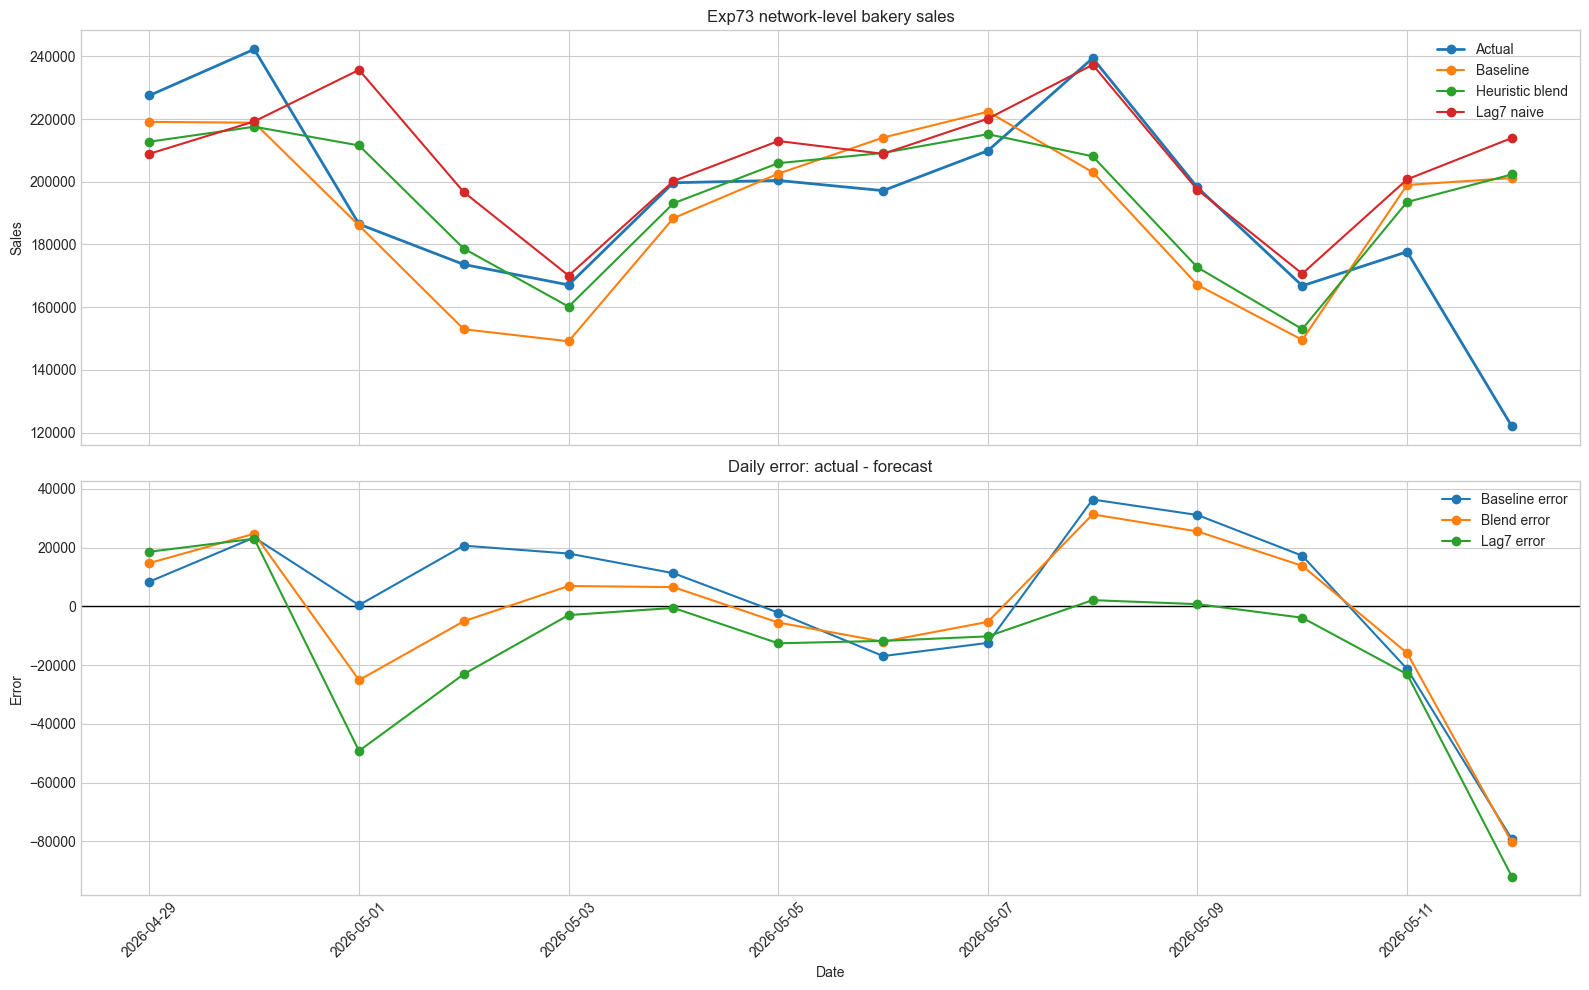

In [5]:
plot_network_forecast(latest_backtest)


,model,mae,mse,wmape,bias
0,lag7,175.674143,56938.465343,14.142400,108.147000
1,blend,215.945129,83856.994300,17.384359,159.252278
2,baseline,296.678965,153192.913623,23.883723,247.113910


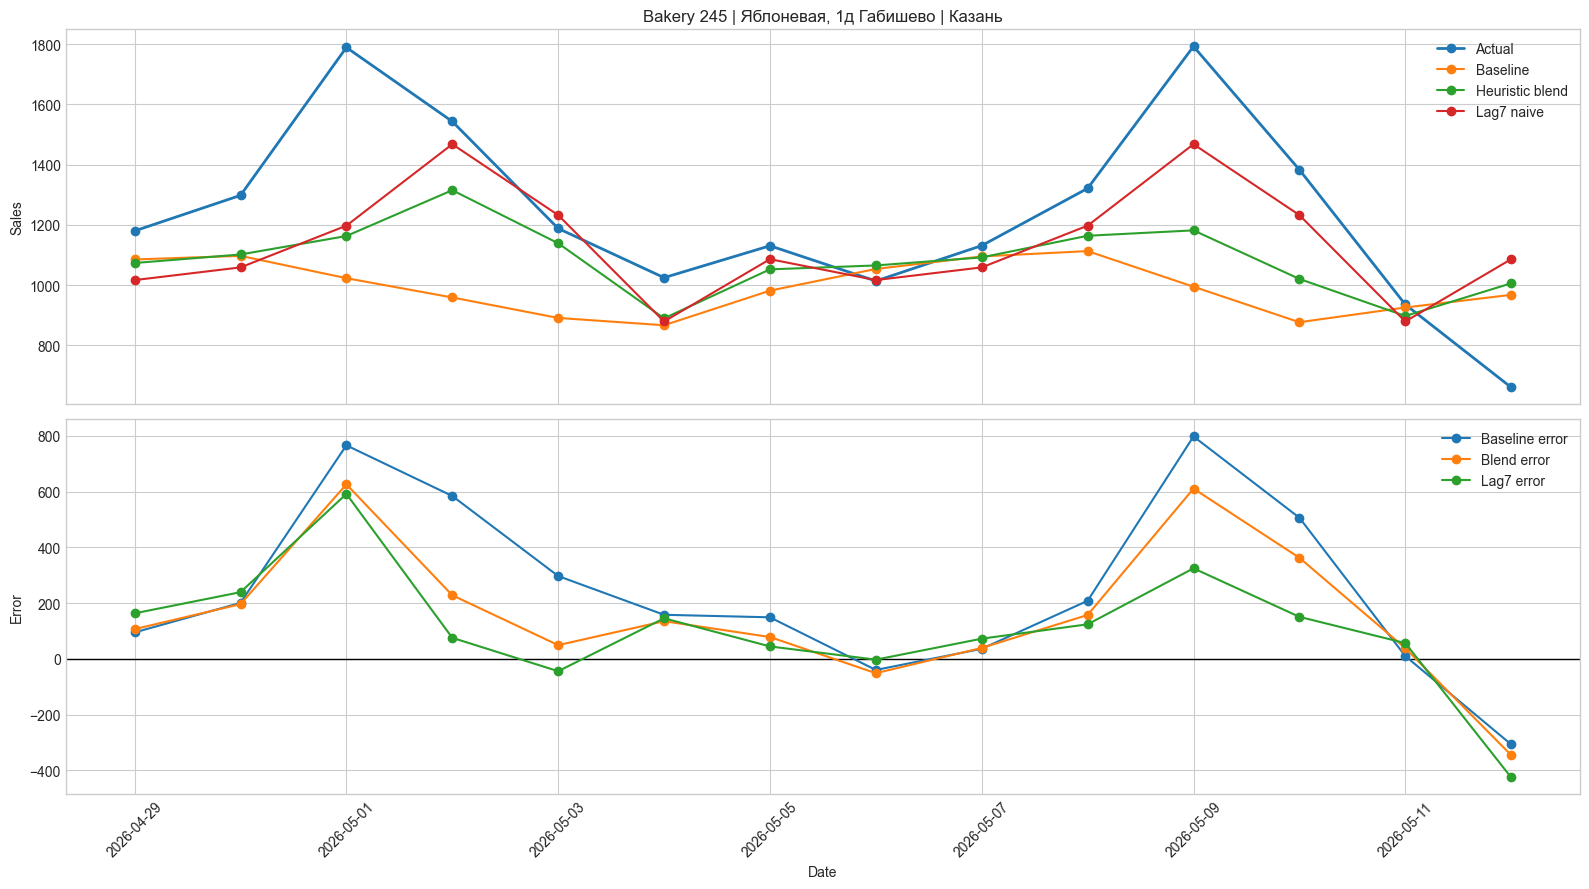

,model,mae,mse,wmape,bias
0,lag7,111.770000,26088.646665,9.691371,-24.911143
1,blend,156.300437,39023.422560,13.552523,59.424043
2,baseline,187.130651,47343.976883,16.225754,28.037899


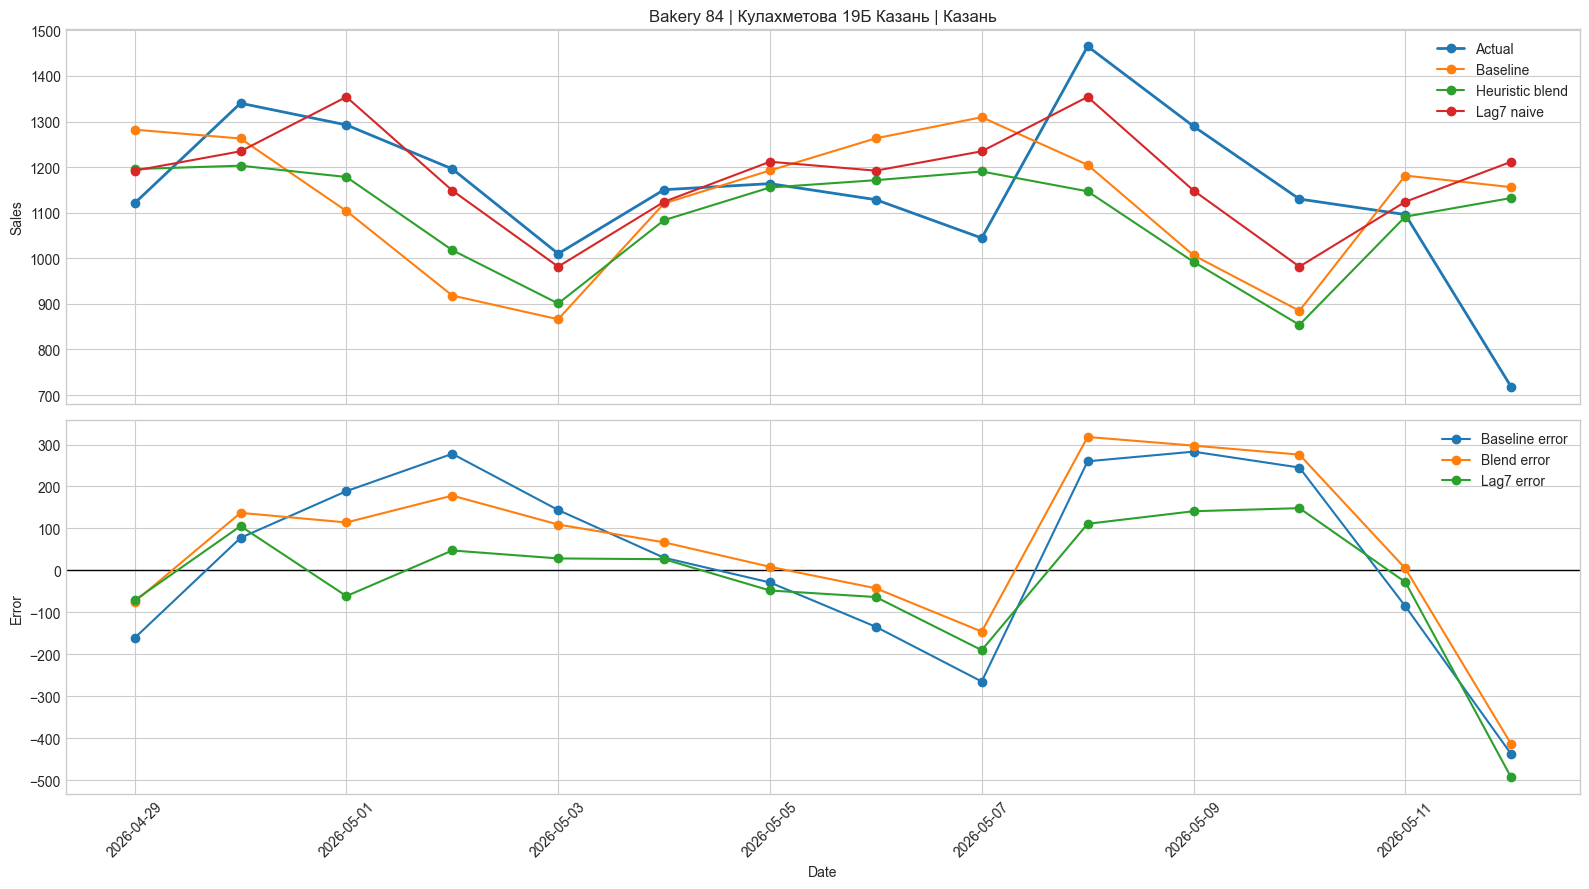

,model,mae,mse,wmape,bias
0,lag7,111.770000,26088.646665,9.691371,-24.911143
1,blend,156.300437,39023.422560,13.552523,59.424043
2,baseline,187.130651,47343.976883,16.225754,28.037899


In [6]:
# Example bakeries from the latest exp73 analysis.
plot_bakery_forecast(latest_backtest, bakery_id=245)
plot_bakery_forecast(latest_backtest, bakery_id=84)


## Exp74 30-Day Non-Recursive Holdout

This section loads the 30-day non-recursive holdout from `src/experiments_v2/74_bakery_non_recursive/30d/`.
It compares:
- `daily_baseline_non_recursive`
- `heuristic_blend_non_recursive`
- `seasonal_naive_lag7_non_recursive`


In [9]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.bakery_day_backtest_exp74 import build_bakery_model_summary
from notebooks.bakery_day_backtest_exp74 import build_model_summary
from notebooks.bakery_day_backtest_exp74 import load_exp74_backtest
from notebooks.bakery_day_backtest_exp74 import plot_bakery_forecast
from notebooks.bakery_day_backtest_exp74 import plot_network_forecast

exp74_30d_backtest = load_exp74_backtest(ROOT, run_name="30d")
exp74_30d_summary = build_model_summary(exp74_30d_backtest)
exp74_30d_bakery_summary = build_bakery_model_summary(exp74_30d_backtest)

display(exp74_30d_summary)
display(exp74_30d_bakery_summary.sort_values("blend_minus_baseline_mae").head(20))
display(exp74_30d_bakery_summary.sort_values("lag7_minus_blend_mae").head(20))


,model,mae,mse,wmape,bias
0,baseline,135.337706,38157.764407,12.631876,-6.813049
1,blend,168.067158,64566.178506,15.686711,-21.119658
2,lag7,222.854511,133225.084103,20.800341,-23.317803


,bakery_id,bakery_name,city,lag7_mae,lag7_wmape,lag7_bias,baseline_mae,baseline_wmape,baseline_bias,blend_mae,blend_wmape,blend_bias,best_model,best_mae,blend_minus_baseline_mae,lag7_minus_blend_mae
164,245,"Яблоневая, 1д Габишево",Казань,148.717600,12.998574,33.202733,186.307431,16.284091,118.512601,143.657757,12.556321,41.693325,blend,143.657757,-42.649674,5.059843
117,160,Альфии Авзаловой 5 Казань,Казань,128.245433,11.973357,-17.198833,137.802639,12.865645,59.797861,114.306540,10.671982,14.703881,blend,114.306540,-23.496098,13.938893
178,264,Теплых встреч 7 Казань,Казань,90.560600,10.460061,-53.347000,116.627753,13.470907,-55.662306,100.871446,11.650999,-59.623901,lag7,90.560600,-15.756308,-10.310846
147,218,Проспект Победы 147 Казань,Казань,92.411267,10.643894,-12.164000,93.048538,10.717295,64.772760,80.048973,9.220010,27.320021,blend,80.048973,-12.999564,12.362293
112,155,Тэцевская 4Д Казань,Казань,121.722800,8.773057,-57.788733,120.317713,8.671787,-15.137693,108.422114,7.814422,-30.795622,blend,108.422114,-11.895599,13.300686
114,157,Ильгама Шакирова 5 Казань,Казань,87.019567,13.158184,-41.191233,88.384975,13.364647,-41.000512,77.388862,11.701930,-38.815575,blend,77.388862,-10.996113,9.630705
83,103,Татарстан 16 Наб Челны,Набережные Челны,179.454800,14.257118,-36.063267,142.811695,11.345939,85.108591,133.437415,10.601182,1.121801,blend,133.437415,-9.374280,46.017385
177,263,Серова 26 Казань,Казань,74.573433,9.369771,-38.497700,74.517499,9.362744,-11.940351,65.633765,8.246548,-26.085379,blend,65.633765,-8.883734,8.939669
154,230,Шаляпина 26 Казань,Казань,112.043900,12.377714,-31.729167,106.793662,11.797710,31.752122,100.442050,11.096034,-9.604863,blend,100.442050,-6.351612,11.601850
169,254,Ярдем 25 Казань,Казань,91.655167,13.722951,-21.249033,83.982519,12.574174,4.782656,77.977917,11.675142,-8.875621,blend,77.977917,-6.004602,13.677249


,bakery_id,bakery_name,city,lag7_mae,lag7_wmape,lag7_bias,baseline_mae,baseline_wmape,baseline_bias,blend_mae,blend_wmape,blend_bias,best_model,best_mae,blend_minus_baseline_mae,lag7_minus_blend_mae
178,264,Теплых встреч 7 Казань,Казань,90.560600,10.460061,-53.347000,116.627753,13.470907,-55.662306,100.871446,11.650999,-59.623901,lag7,90.560600,-15.756308,-10.310846
175,261,Строителей 6 Новочебоксарск,Чебоксары,50.952200,15.052730,-8.137133,51.397822,15.184379,6.497415,46.890422,13.852765,-8.219053,blend,46.890422,-4.507399,4.061778
164,245,"Яблоневая, 1д Габишево",Казань,148.717600,12.998574,33.202733,186.307431,16.284091,118.512601,143.657757,12.556321,41.693325,blend,143.657757,-42.649674,5.059843
148,219,Горьковское шоссе 2Ак1 Казань,Казань,92.204333,13.565222,-18.799133,80.484203,11.840941,19.632482,87.114217,12.816357,-8.523064,baseline,80.484203,6.630013,5.090117
141,189,Нурихана Фаттаха 21/1 Казань,Казань,54.563467,17.974477,-23.968400,43.517708,14.335747,-15.202428,47.555091,15.665755,-17.627250,baseline,43.517708,4.037383,7.008376
99,130,Сармановский тракт 68 Наб Челны,Набережные Челны,78.426067,11.799613,-0.463733,72.533311,10.913017,8.240207,70.970539,10.677890,-6.132864,blend,70.970539,-1.562772,7.455528
123,169,Державина 9б Сокуры,Казань,153.494433,12.766440,-22.296300,147.502665,12.268093,31.654111,145.548777,12.105584,2.310727,blend,145.548777,-1.953888,7.945656
177,263,Серова 26 Казань,Казань,74.573433,9.369771,-38.497700,74.517499,9.362744,-11.940351,65.633765,8.246548,-26.085379,blend,65.633765,-8.883734,8.939669
104,143,Фучика 94 Казань,Казань,81.342300,14.029171,-21.917900,75.060556,12.945754,9.136440,72.184733,12.449758,-10.447318,blend,72.184733,-2.875823,9.157567
136,183,Камая 8а Казань,Казань,82.300300,15.949082,-25.905833,64.132342,12.428290,0.871215,73.129683,14.171896,-10.419036,baseline,64.132342,8.997341,9.170617


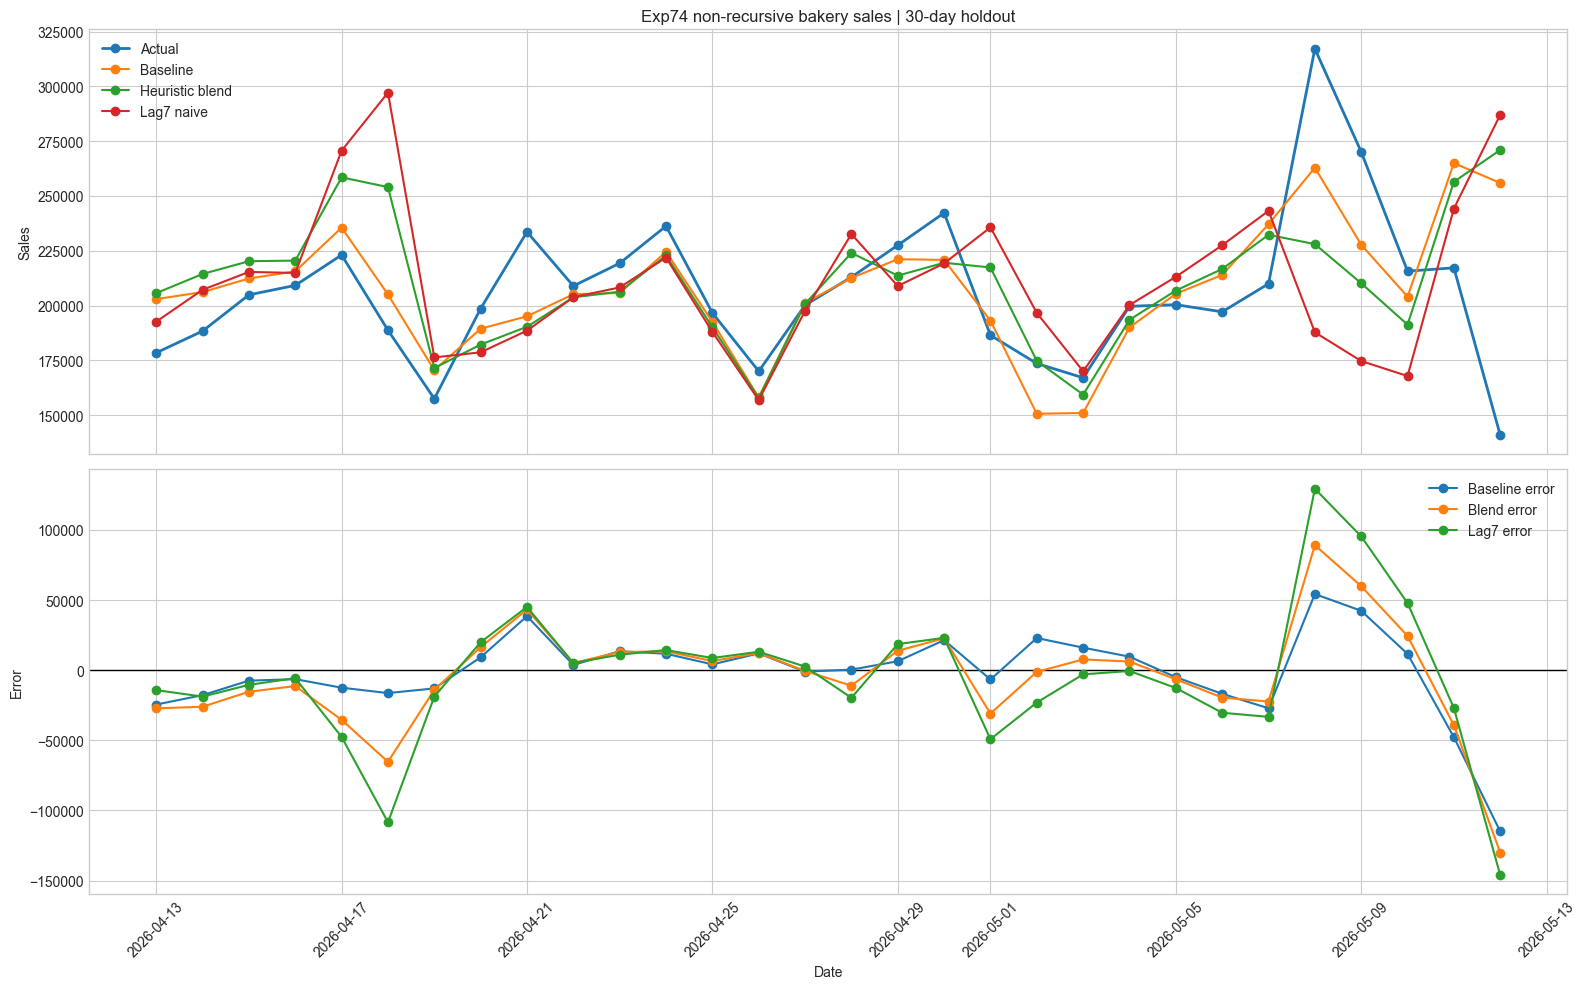

In [10]:
plot_network_forecast(exp74_30d_backtest, title_suffix=" | 30-day holdout")


,model,mae,mse,wmape,bias
0,blend,143.657757,38912.904252,12.556321,41.693325
1,lag7,148.717600,42592.496958,12.998574,33.202733
2,baseline,186.307431,62042.534796,16.284091,118.512601


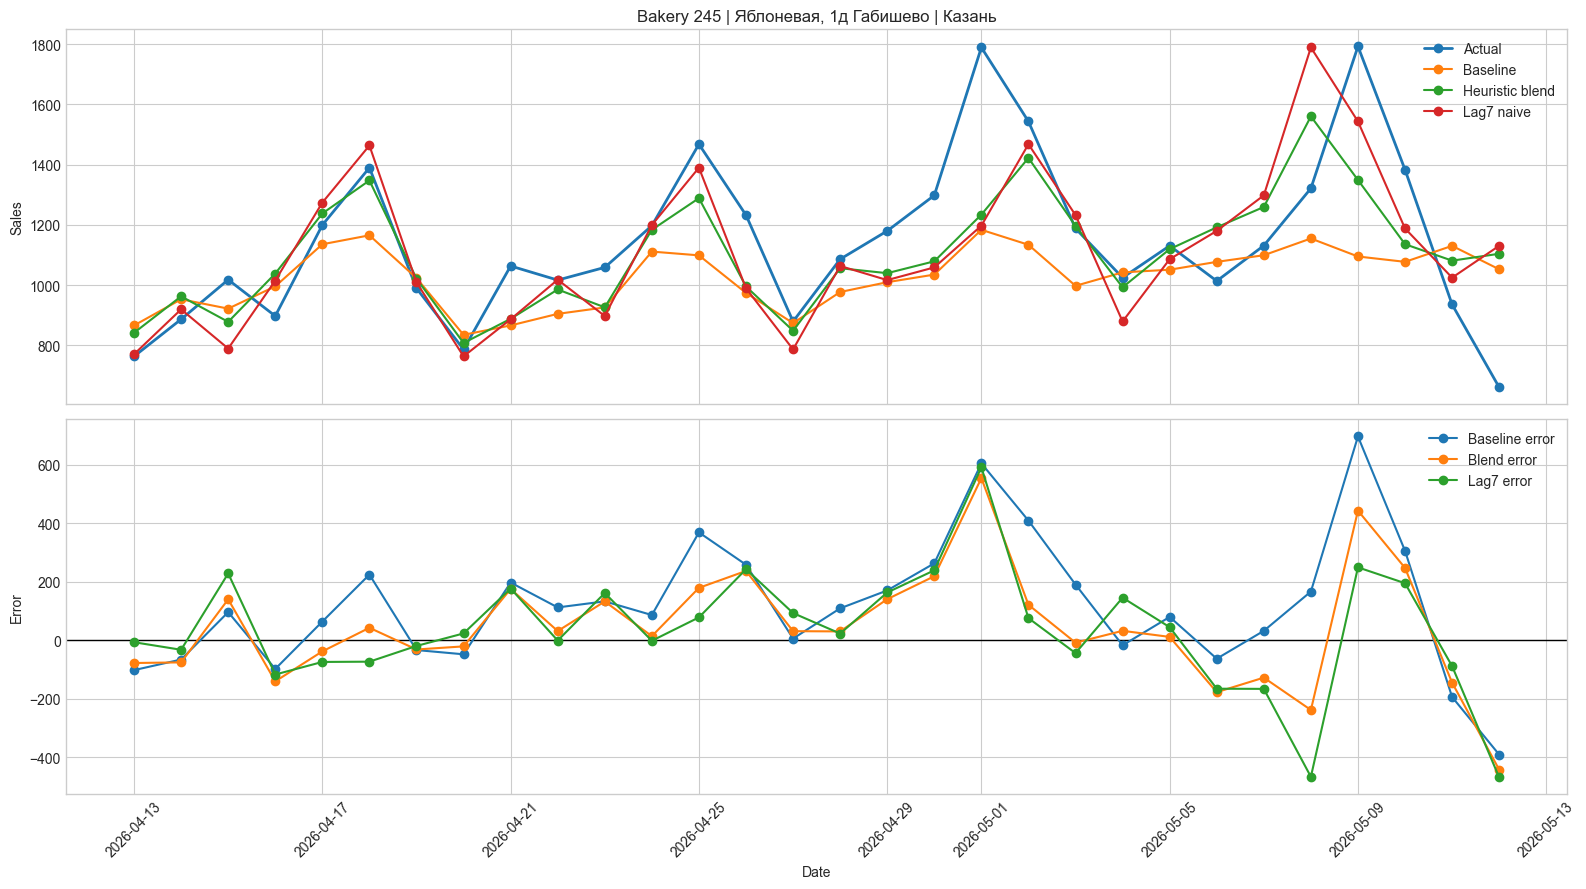

,model,mae,mse,wmape,bias
0,baseline,117.667203,22906.345786,10.064354,-21.581573
1,blend,151.485044,42919.430765,12.956874,-43.846526
2,lag7,170.910333,86387.440686,14.618365,-94.251400


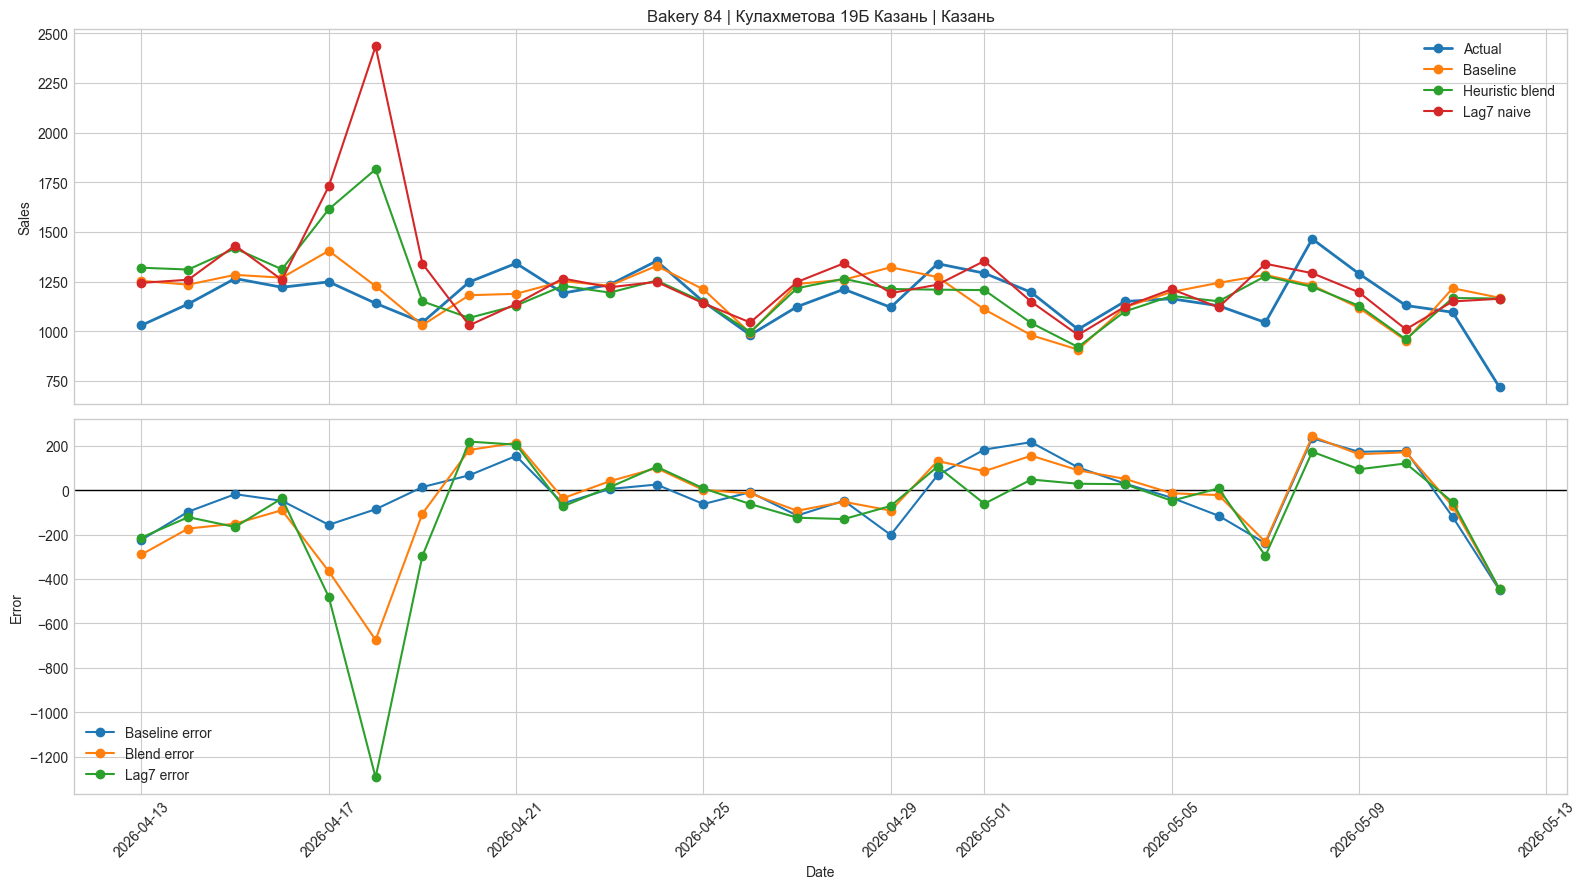

,model,mae,mse,wmape,bias
0,baseline,77.475746,9917.351958,16.195327,-58.499600
1,blend,89.109080,12628.907345,18.627129,-43.557977
2,lag7,118.400000,24999.350000,24.750026,-56.733333


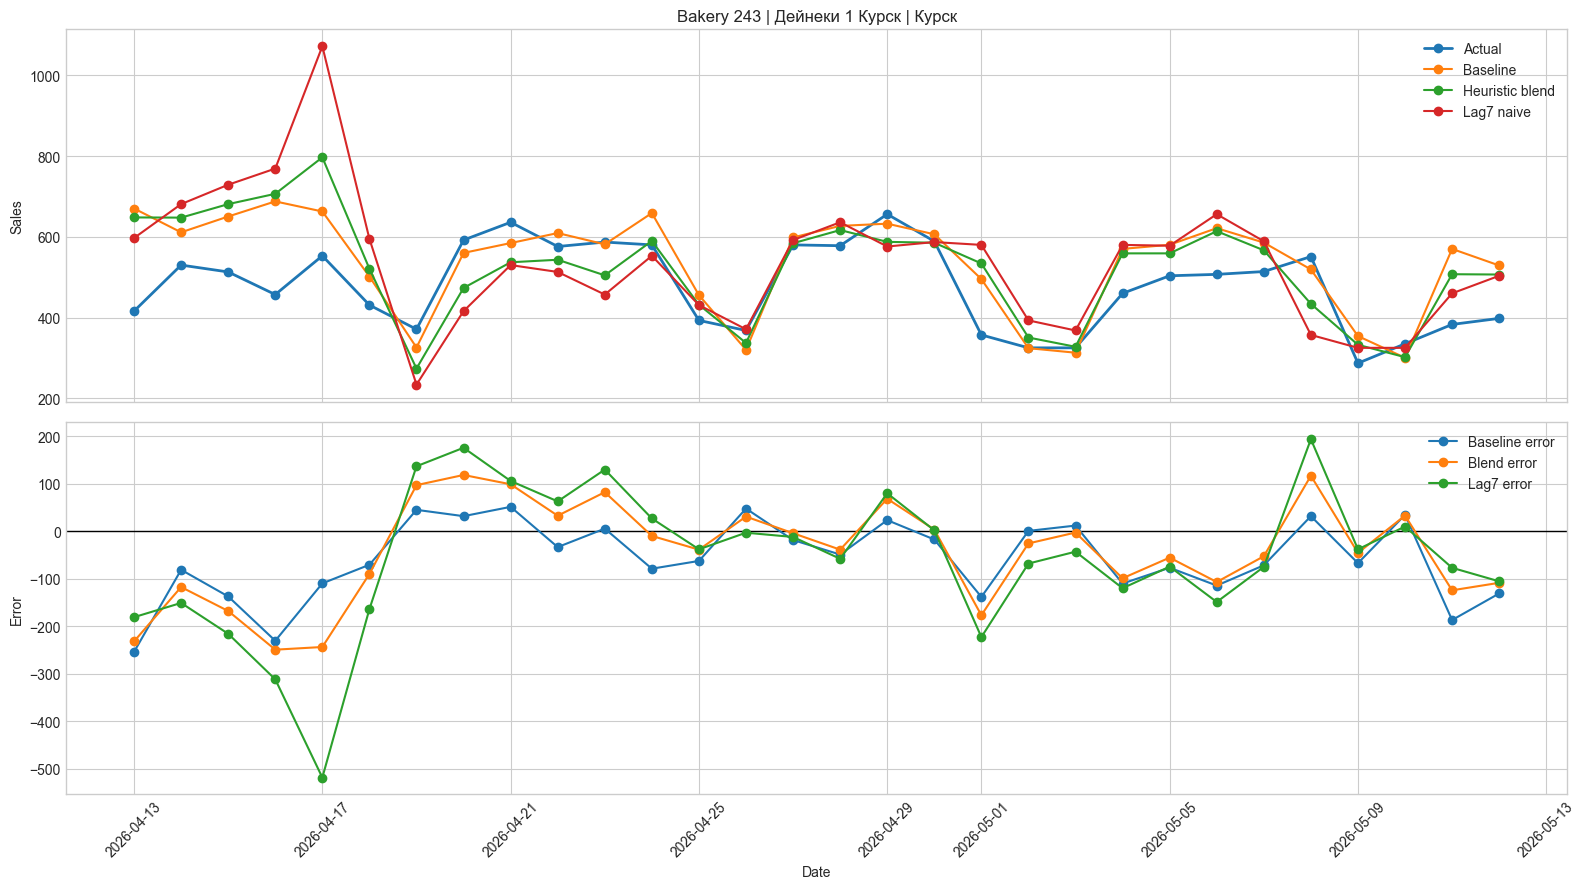

,model,mae,mse,wmape,bias
0,baseline,122.072573,25968.902013,10.595127,-28.949055
1,blend,167.269699,46816.821695,14.517952,-49.923581
2,lag7,210.730600,79704.729552,18.290084,-78.821733


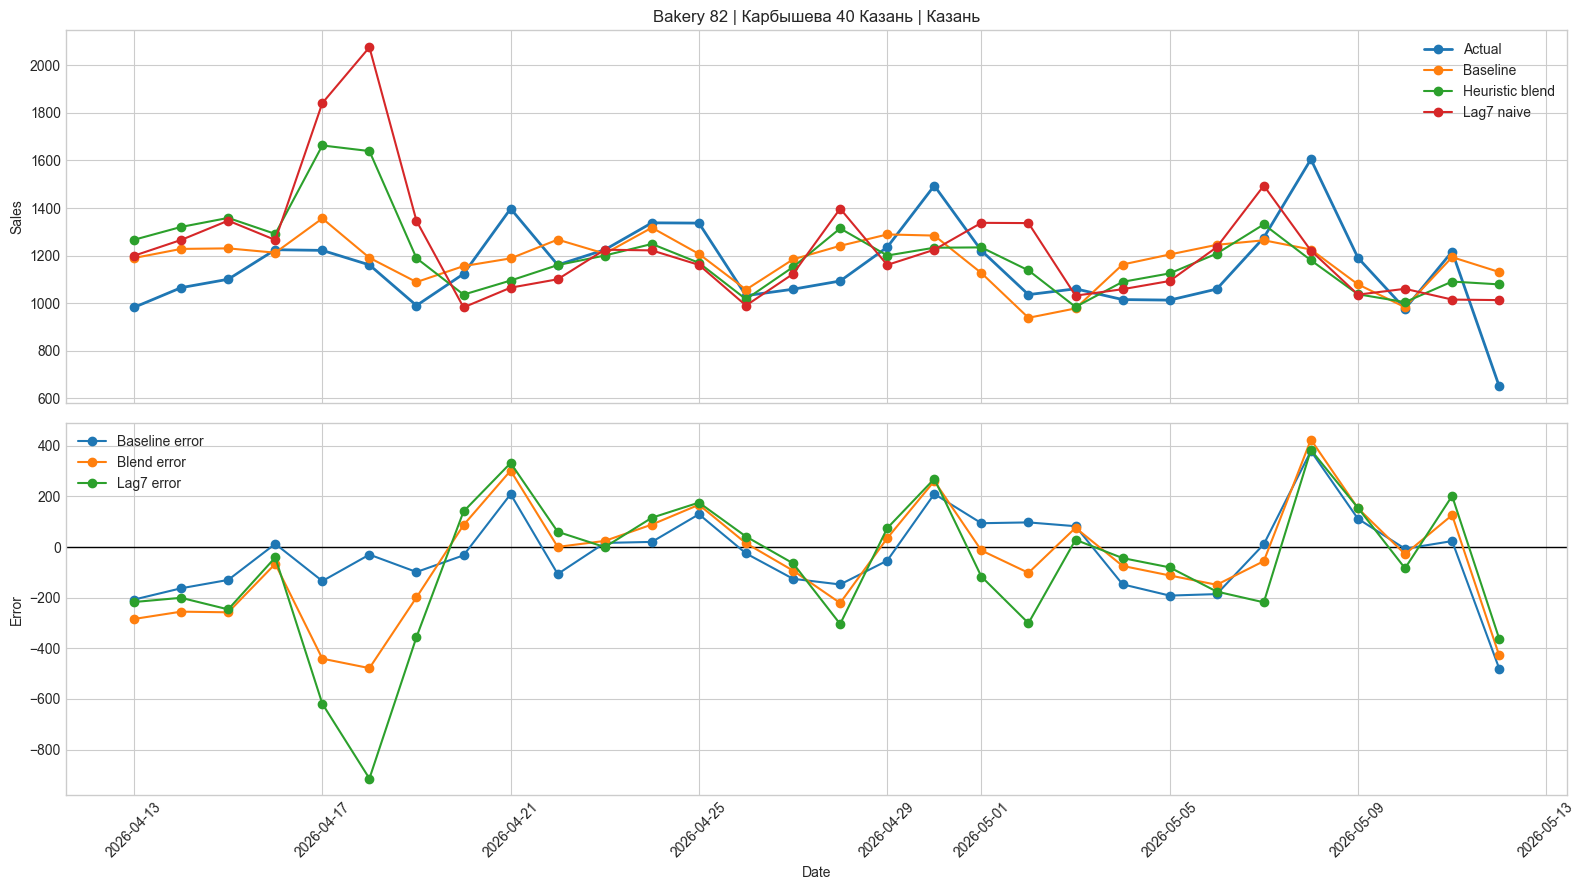

,model,mae,mse,wmape,bias
0,baseline,115.750786,22179.193742,12.951632,-24.532286
1,blend,138.160950,36213.021538,15.459159,-31.464055
2,lag7,184.736733,64892.288497,20.670635,-65.580867


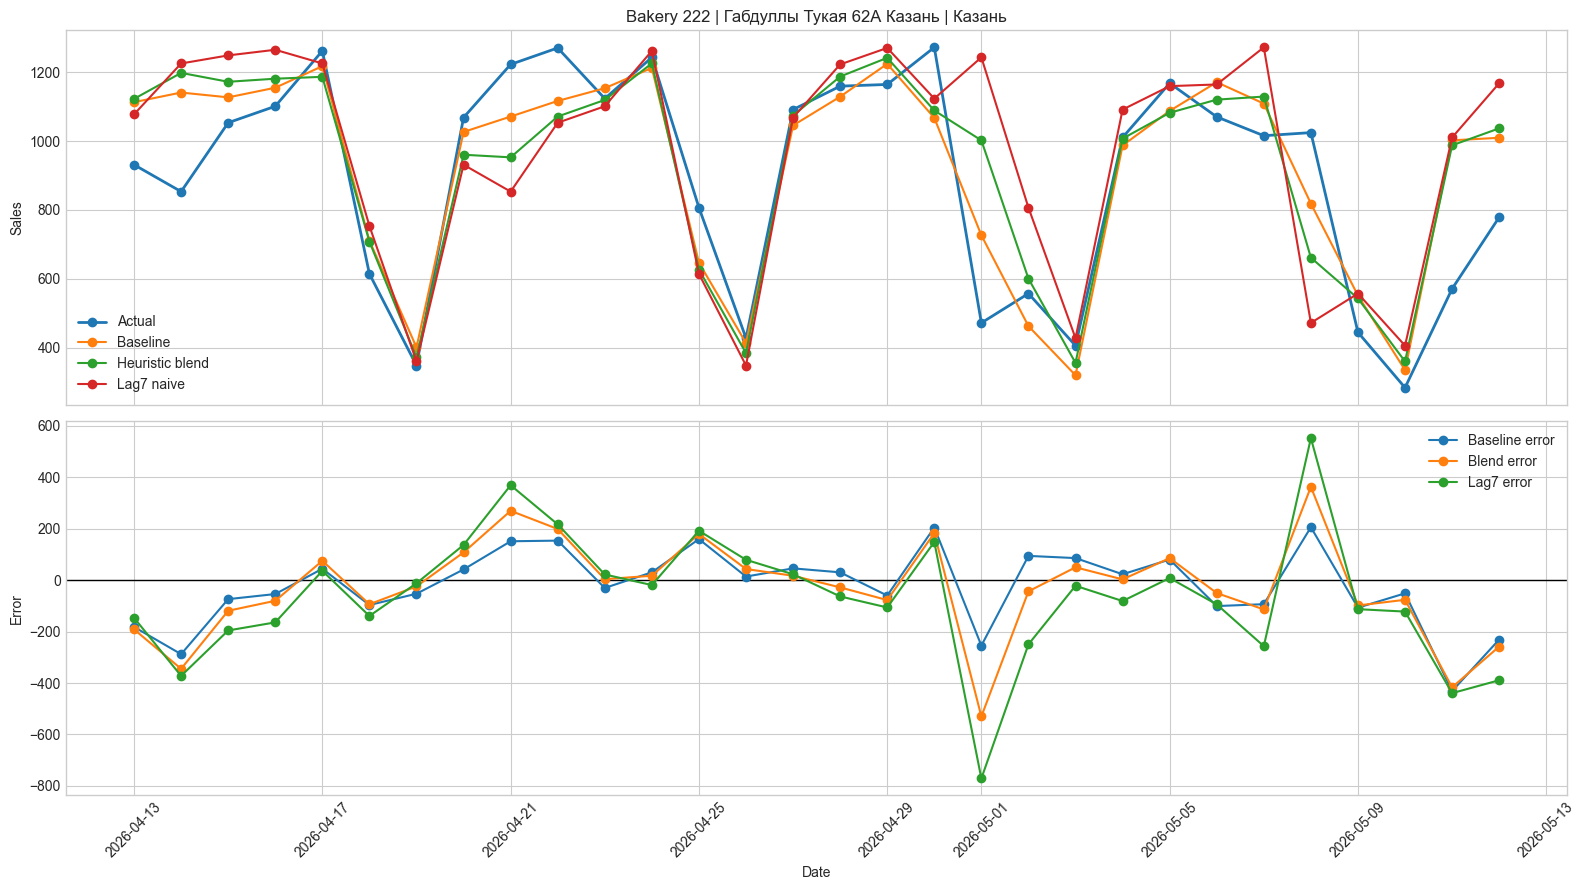

,model,mae,mse,wmape,bias
0,baseline,122.803156,21317.101960,11.383629,24.68804
1,blend,150.289501,33444.858634,13.931563,-20.33102
2,lag7,174.054300,52873.105171,16.134517,-36.24770


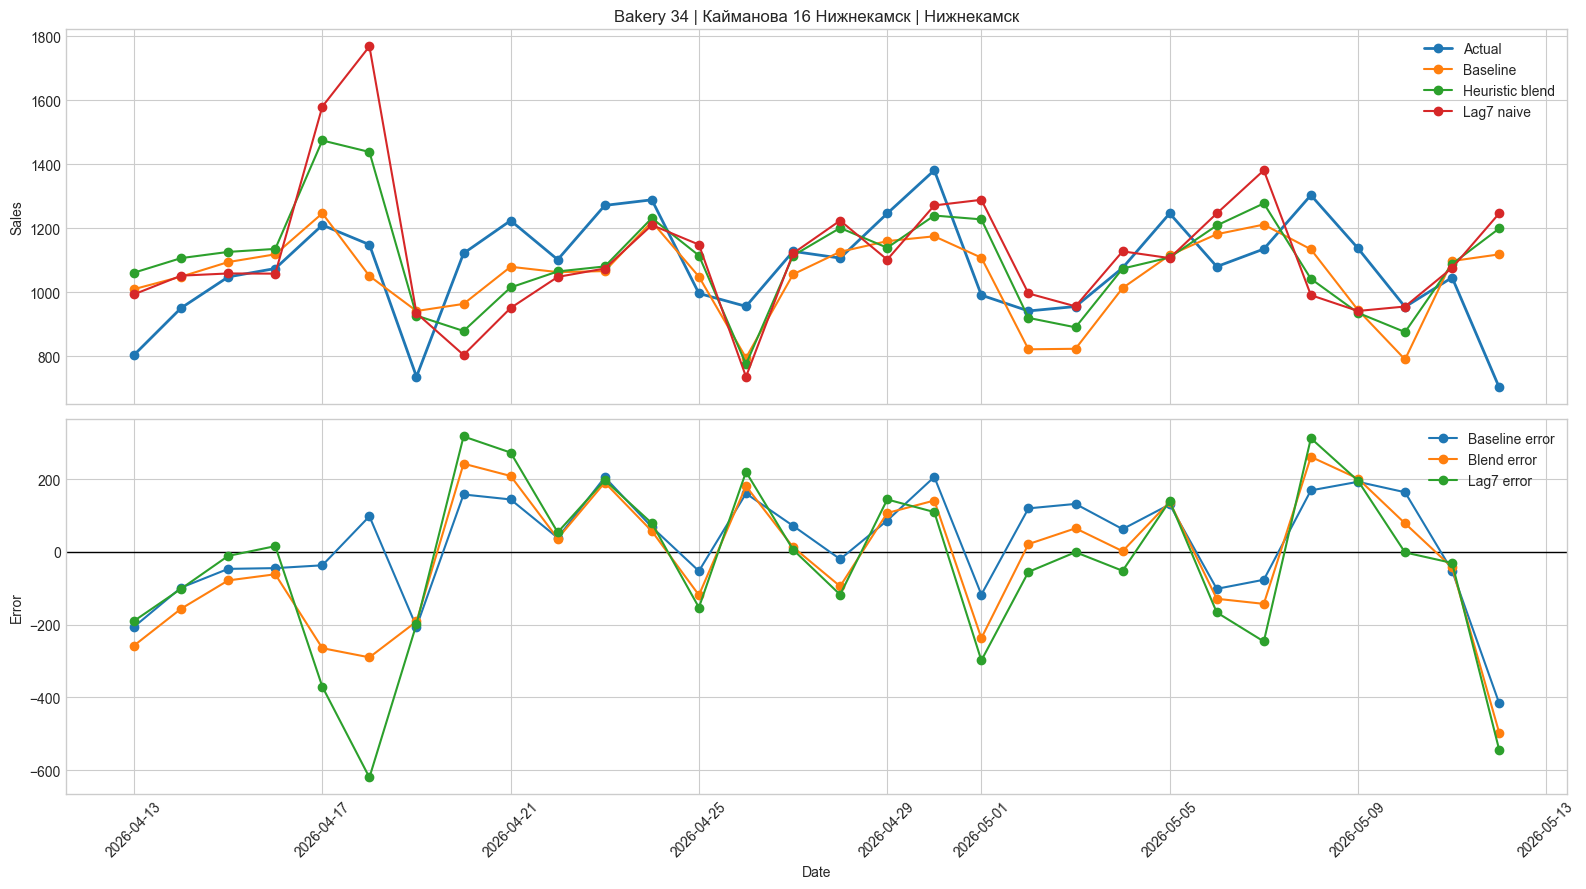

,model,mae,mse,wmape,bias
0,baseline,122.803156,21317.101960,11.383629,24.68804
1,blend,150.289501,33444.858634,13.931563,-20.33102
2,lag7,174.054300,52873.105171,16.134517,-36.24770


In [13]:
plot_bakery_forecast(exp74_30d_backtest, bakery_id=245)
plot_bakery_forecast(exp74_30d_backtest, bakery_id=84)
plot_bakery_forecast(exp74_30d_backtest, bakery_id=243)
plot_bakery_forecast(exp74_30d_backtest, bakery_id=82)
plot_bakery_forecast(exp74_30d_backtest, bakery_id=222)
plot_bakery_forecast(exp74_30d_backtest, bakery_id=34)


,model,mae,mse,wmape,bias
0,baseline,131.260749,28034.052516,12.158693,16.746921
1,blend,168.226733,43680.713268,15.582855,-20.989866
2,lag7,199.246667,66343.725407,18.456233,-49.466667


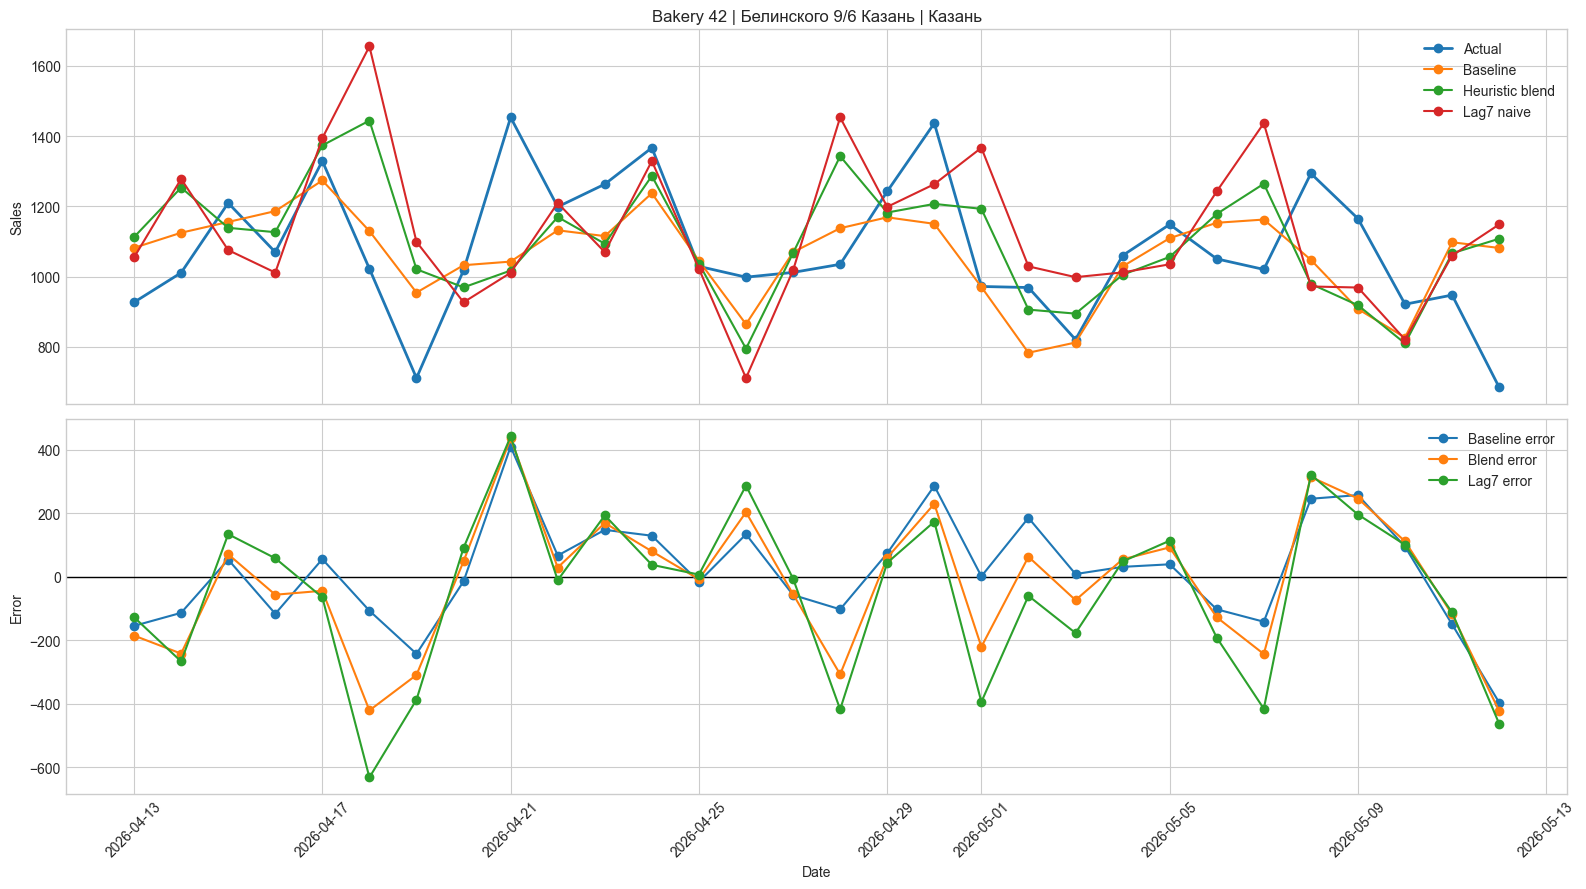

,model,mae,mse,wmape,bias
0,baseline,131.260749,28034.052516,12.158693,16.746921
1,blend,168.226733,43680.713268,15.582855,-20.989866
2,lag7,199.246667,66343.725407,18.456233,-49.466667


In [55]:
plot_bakery_forecast(exp74_30d_backtest, bakery_id=42)

## Exp74 30-Day Run Comparison

Compare three 30-day non-recursive runs:
- `30d`
- `30d_targeted_holiday_overrides`
- `30d_cluster_features`


In [56]:
from bakery_day_backtest_exp74 import compare_exp74_bakery_runs
from bakery_day_backtest_exp74 import compare_exp74_runs
from bakery_day_backtest_exp74 import plot_exp74_run_comparison


In [57]:
run_compare = compare_exp74_runs(ROOT, run_names=[
    "30d",
    "30d_targeted_holiday_overrides",
    "30d_cluster_features",
])
display(run_compare)


run_name                              model        30d                                                                            30d_cluster_features  \
                                              avg_bias     avg_mae       avg_mse  avg_wmape median_abs_bias  median_mae win_count             avg_bias   
0              daily_baseline_non_recursive  -4.395673  121.780982  31233.010642  11.693223       21.474782  115.011257     159.0             1.067049   
1             heuristic_blend_non_recursive -29.726287  145.685980  46419.176270  13.795378       30.281022  133.801787      22.0           -27.429468   
2         seasonal_naive_lag7_non_recursive -52.053701  181.583510  80959.617240  17.184567       53.675833  156.776750       1.0           -52.053701   

run_name                                                                            30d_targeted_holiday_overrides                                       \
             avg_mae       avg_mse  avg_wmape median_abs_bias  median_mae win_count                       avg_bias     avg_mae       avg_mse  avg_wmape   
0         111.349453  27479.197793  10.632754       22.818345  102.099858     165.0                      -2.182123  120.144175  30556.722313  11.524603   
1         139.134028  43155.887102  13.184295       28.420155  127.253429      16.0                     -28.870594  145.073483  45754.140188  13.734595   
2         181.583510  80959.617240  17.184567       53.675833  156.776750       1.0                     -52.053701  181.583510  80959.617240  17.184567   

run_name                                        
         median_abs_bias  median_mae win_count  
0              23.586514  113.165621     161.0  
1              28.801555  132.938723      20.0  
2              53.675833  156.776750       1.0

In [58]:
baseline_delta = compare_exp74_bakery_runs(
    ROOT,
    baseline_run="30d",
    candidate_run="30d_cluster_features",
    model_name="baseline",
)
display(baseline_delta.head(20))
display(baseline_delta.tail(20))


,bakery_id,bakery_name,city,30d_baseline_mae,30d_baseline_wmape,30d_baseline_bias,30d_cluster_features_baseline_mae,30d_cluster_features_baseline_wmape,30d_cluster_features_baseline_bias,30d_cluster_features_minus_30d_baseline_mae,30d_cluster_features_minus_30d_baseline_wmape,30d_cluster_features_minus_30d_baseline_bias
0,259,Победы 139к3 ЖК Победа Казань,Казань,144.174795,10.496580,-13.987983,108.970108,7.933518,25.009258,-35.204687,-2.563061,38.997241
1,25,Фучика 30 Казань,Казань,295.284420,9.438933,61.011653,264.632987,8.459142,76.465052,-30.651433,-0.979790,15.453400
2,12,Восстания 117 Казань,Казань,166.190605,11.011245,-63.295650,136.348617,9.034012,-58.161200,-29.841988,-1.977232,5.134450
3,83,Карла Маркса 19 Чебоксары,Чебоксары,143.211313,13.140483,-11.048181,114.639941,10.518891,-3.729823,-28.571371,-2.621592,7.318358
4,256,Булатова 1А Казань,Казань,159.849784,17.708681,-36.112029,132.212260,14.646906,-16.014247,-27.637524,-3.061775,20.097782
5,108,Чулман 9 Нижнекамск,Нижнекамск,141.576717,10.632566,16.470792,114.590869,8.605899,25.433157,-26.985848,-2.026667,8.962365
6,29,Айдарова 8А корп 1 Казань,Казань,196.724244,10.494946,-45.106383,170.699301,9.106554,-31.218219,-26.024943,-1.388392,13.888164
7,19,Хади Такташ 73 Казань,Казань,136.190889,9.567193,-57.700694,110.932407,7.792825,-47.332497,-25.258482,-1.774368,10.368198
8,79,Ильича 19/43 Казань,Казань,207.049454,8.599586,14.091867,181.840345,7.552552,-6.271588,-25.209108,-1.047034,-20.363455
9,9,Закиева 5 Казань,Казань,111.202027,9.965556,40.623799,86.102553,7.716225,41.566545,-25.099475,-2.249332,0.942745


,bakery_id,bakery_name,city,30d_baseline_mae,30d_baseline_wmape,30d_baseline_bias,30d_cluster_features_baseline_mae,30d_cluster_features_baseline_wmape,30d_cluster_features_baseline_bias,30d_cluster_features_minus_30d_baseline_mae,30d_cluster_features_minus_30d_baseline_wmape,30d_cluster_features_minus_30d_baseline_bias
162,65,Можайского 2/37 Казань,Казань,77.917005,7.597852,1.842052,77.479423,7.555183,9.435985,-0.437582,-0.042670,7.593933
163,175,Энтузиастов 31 Чебоксары,Чебоксары,64.141529,9.086704,-16.274832,63.744742,9.030493,-8.825141,-0.396786,-0.056211,7.449691
164,254,Ярдем 25 Казань,Казань,83.982519,12.574174,4.782656,83.965263,12.571590,10.544913,-0.017256,-0.002584,5.762257
165,160,Альфии Авзаловой 5 Казань,Казань,137.802639,12.865645,59.797861,137.832998,12.868479,62.686638,0.030359,0.002834,2.888778
166,32,Проспект Победы 1-06А Заинск,Заинск,125.471086,13.782146,-41.544152,125.639296,13.800623,-31.761247,0.168210,0.018477,9.782905
167,15,Чуйкова 40 Казань,Казань,117.402143,8.885799,32.430905,117.684367,8.907160,37.423251,0.282225,0.021361,4.992346
168,81,Камая 1 Казань,Казань,93.881013,7.653922,13.761094,95.378571,7.776014,20.864203,1.497558,0.122093,7.103109
169,156,Олимпийская 5 Казань,Казань,99.613344,7.770409,16.278389,101.915968,7.950027,28.694162,2.302624,0.179618,12.415773
170,169,Державина 9б Сокуры,Казань,147.502665,12.268093,31.654111,149.837071,12.462250,52.807482,2.334406,0.194157,21.153370
171,36,Химиков 15В Нижнекамск,Нижнекамск,89.002507,7.659724,20.919475,92.099502,7.926257,21.857650,3.096996,0.266533,0.938175


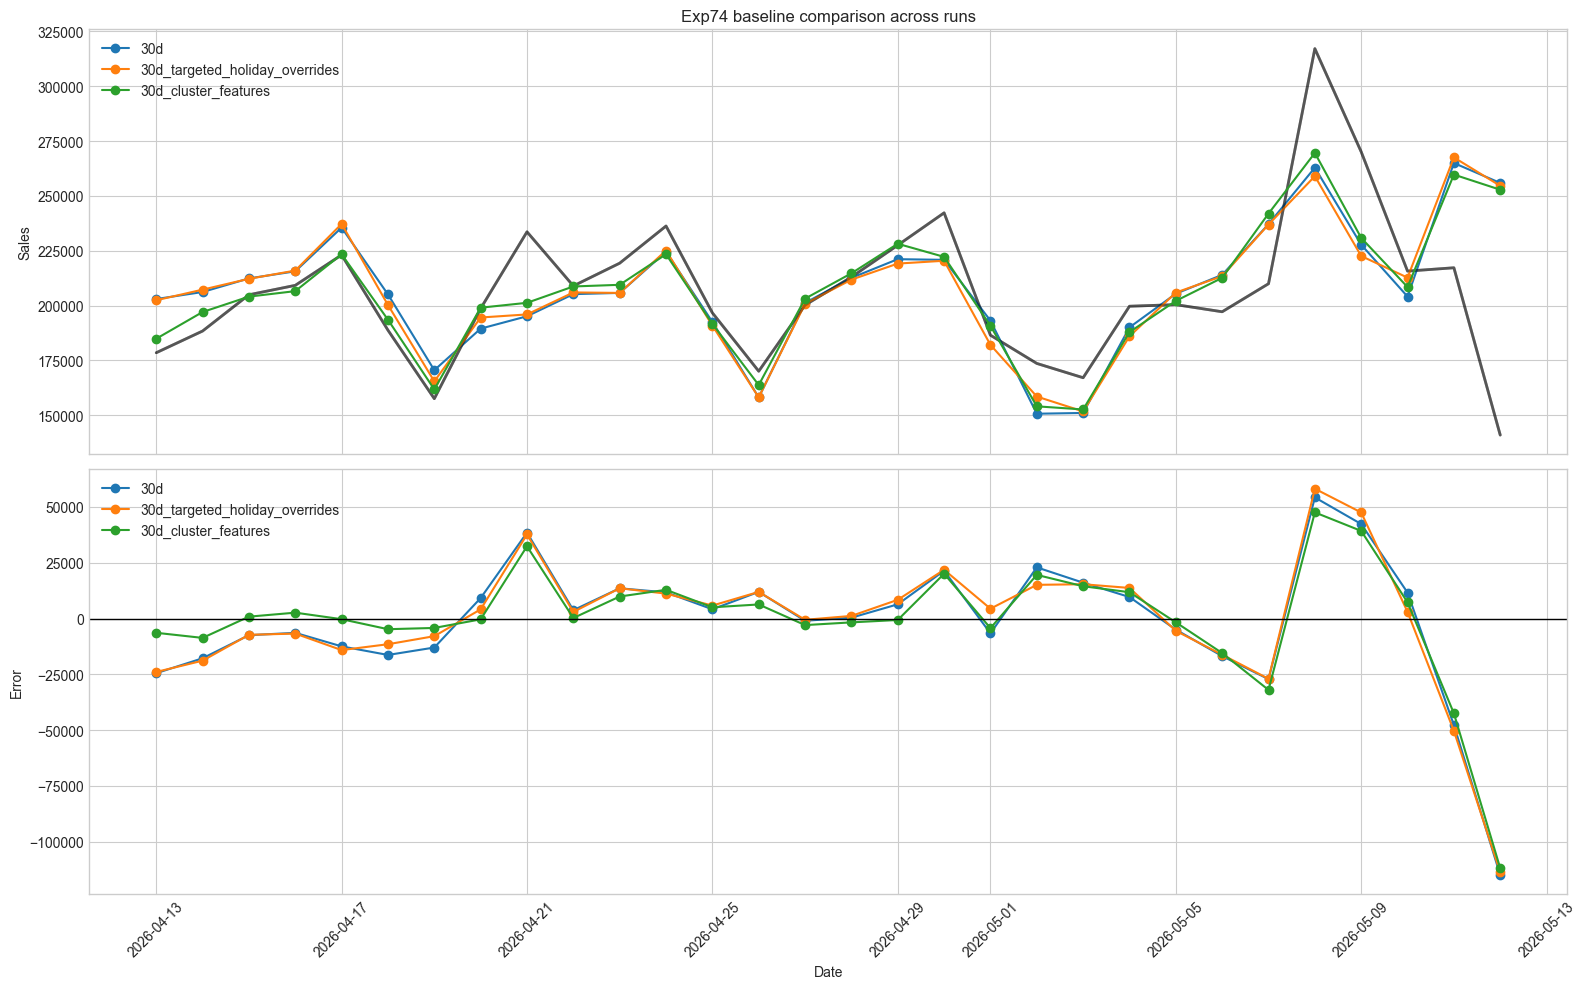

In [59]:
plot_exp74_run_comparison(
    ROOT,
    run_names=["30d", "30d_targeted_holiday_overrides", "30d_cluster_features"],
    model_name="baseline",
)


,model,mae,mse,wmape,bias
0,baseline,181.840345,69660.990049,7.552552,-6.271588
1,blend,272.305612,141379.828302,11.309934,-50.893813
2,lag7,352.641200,274414.053701,14.646590,-102.820600


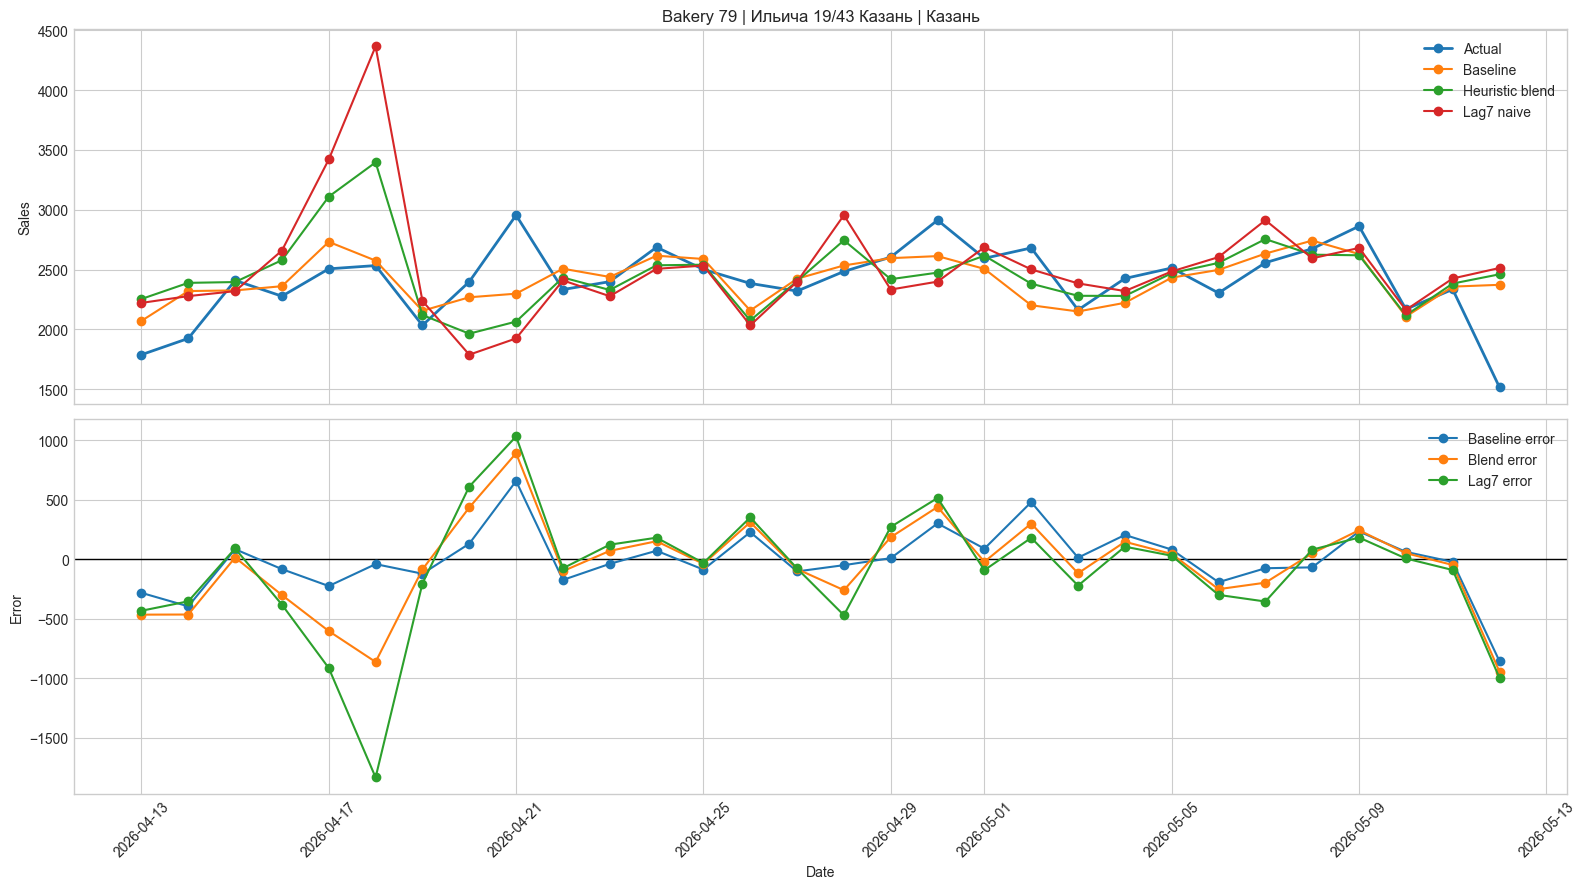

,model,mae,mse,wmape,bias
0,baseline,181.840345,69660.990049,7.552552,-6.271588
1,blend,272.305612,141379.828302,11.309934,-50.893813
2,lag7,352.641200,274414.053701,14.646590,-102.820600


In [111]:
from bakery_day_backtest_exp74 import load_exp74_backtest
from bakery_day_backtest_exp74 import plot_bakery_forecast

exp74_cluster = load_exp74_backtest(ROOT, run_name="30d_cluster_features")
plot_bakery_forecast(exp74_cluster, bakery_id=79)

# Для другой пекарни:

# plot_bakery_forecast(exp74_cluster, bakery_id=84)

# Если хочешь искать по имени, а не по bakery_id:

# plot_bakery_forecast(
#     exp74_cluster,
#     bakery_name_contains="Зеленодольск",
# )